# Author: Lena Noack
# GNU General Public License v3.0 (GPL-3.0)
#Interior Structure Model


In [1]:
import numpy as np
import math
import csv
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
from EOS_functions import EOS_rock, EOS_core, EOS_core_mixed
from values import *
from Help_functions import get_Tmelt_MO, get_Tmelt_core, get_Tmelt_water, getphase
from water import getWater


# Start interior structure model with the temperature and pressure equation.


In [3]:
def temp_pla2(T_e, R_e, a):
    t_p=T_e*(R_e/(2*a))**(1/2)
    return t_p

# Units: 1, kg, kg, km, km 
def pressao(P_t, M_p, M_t, R_p, R_t, tipo): 
    if tipo == 1: 
        beta = 1.05*10**(-13)
    elif tipo == 0:
        beta = 108.27
    elif tipo == 2:
        beta = 0.0467
    elif tipo==3 or tipo==4 : 
        beta = 1.014
    else:
        beta=1
    P=beta*((M_p/M_t)**2)*((R_t/R_p)**4)*P_t
    return P*101325

In [4]:
def interior_structure(M,x_Fe_tot,x_H2O_tot, t, P):
  '''
  input:
   M: Mass in Earth masses
   x_Fe_tot: Iron weigth fraction in percent of the entire planet (core + mantle)
   x_H2O_tot: Water weigth fraction in percent of surface water/ice layer
  return:
   Rp_E - planet radius in Earth radii
   MOI - moment of inertia factor
   radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu - profiles of different planetary properties
   mat - material layers (<0 ices, 0 water, >0 different rock and core layers)
  '''

  '''Set initialization parameters'''
  Dcr = 50e3      # thickness of crustal layer in m
  Dlid = 300e3    # thickness of lithosphere, only used to set upper mantle temperature
  Psurf = P     # atmospheric surface pressure
  Tsurf = t     # potential surface temperature in K
  Tlid = 0.0    #2000 # in K; if set to 0, then mantle melt temp is used at Dlid depth to set Tlid
  DTcmb = -1.0  #1500 # in K, T jump at CMB; if set to neg value (e.g. -1), then jump is calculated via melt temp times -DTcmb
  nr = 500         # radial resolution from center of planet to surface
  tol = 0.001     # Convergence parameter
  maxIter = 20   # max number iterations

  # light elements in the core -> array added for molar fractions Si,C,S,O; e.g. (0.2 S -> Fe0.8S0.2), means weight fraction of 12 wt-% S
  xelem = np.array([0.0,0.0,0.2,0.0]) # initial core-averaged value
  xelem_ic = np.array([0.00,0.00,0.07,0.00]) # fixed inner core value (no real partitioning included yet; outer core value calculated during inner core growth

  X_FeM_mol = 0.1 # iron number in mantle (ratio of Fe-bearing molecules divided by Mg- and Fe-bearing molecules)
  X_H2OM = 0      # water content in mantle in wt-%, only used for el cond profile versions 2-4
  ec_model = 1    # electrical conductivity profiles: 1 - Xu, 2 - mat-dep prof without Fe, 3 - as 2 but with Fe dependence, 4 - as 3 but newer parameters


  '''Distribute iron between core and mantle'''

  x_Fe_tot = x_Fe_tot/100 # weight fraction instead of percent
  x_H2O_tot = x_H2O_tot/100
  M = M * 5.972*10**24 # mass in kg
  Mw = M*x_H2O_tot # would need to be reduced by water stored in mantle, not considered here
  G = 6.67384*10**(-11) # gravitational constant in m^3 / (kg s^2)

  # Take Fe in mantle out of x_Fe to obtain x_CMF (core mass fraction based on iron - here light elements not included yet!)
  # Here we assume that mantle is composed of (1-X_FeM_mol)*Mg2SiO4 + X_FeM_mol*Fe2SiO4

  # Molar masses:
  mMg=24.305; mFe=55.845; mSi=28.0855; mO=15.9994

  XmFe = 2*X_FeM_mol*mFe/(X_FeM_mol*2*(mFe-mMg) + 2*mMg+mSi+4*mO) # mantle mass fraction of iron w.r.t. mantle mass

  # x_Fe_tot*M = x_Fe*M + XmFe*Mm = x_Fe*M*(1-XmFe) + XmFe*(M-Mw)
  x_Fe = ( x_Fe_tot*M - XmFe*(M-Mw) ) / (M*(1-XmFe)) # core mass fraction w.r.t. total planet mass
  Mc = x_Fe*M
  if Mc<0.0:
      print("Error, not enough iron in planet to have ",X_FeM_mol," as iron number -> adapt iron number!")
      Mc = 0.0
      x_Fe = 0.0
      XmFe = x_Fe_tot*M / (M-Mw) # adapt XmFe such that all iron is in mantle

      #XmFe * (X_FeM_mol*2*(mFe-mMg) + 2*mMg+mSi+4*mO) = 2*X_FeM_mol*mFe
      X_FeM_mol = XmFe*(2*mMg+mSi+4*mO)/(2*mFe-2*(mFe-mMg)*XmFe) # adapt mantle iron number

  Mm = M - Mc - Mw

  #print('Iron fraction={0:5.3f}, Core IF={1:5.3f}, Mantle Fe#={2:5.3f}, Mantle IF={3:5.3f}\n'
  #      .format(x_Fe_tot,x_Fe,X_FeM_mol,XmFe*Mm/M))

  '''Initialization routines'''

  rho_c = 11000 # guess for core density in kg/m^3
  rho_m = 4000 # guess for mantle density in kg/m^3
  rho_w = 1000 # guess for water density in kg/m^3
  cp_c = 800 # guess for core heat capacity in J/kg K
  cp_m = 1300 # guess for mantle heat capacity in J/kg K
  cp_w = 4200 # guess for water heat capacity in J/kg K
  alpha_c = 0.00001 # guess for core thermal expansion ceoff. in 1/K
  alpha_m = 0.000025 # guess for mantle thermal expansion ceoff. in 1/K
  alpha_w = 0.00007 # guess for water thermal expansion ceoff. in 1/K

  Rc = ( Mc*3.0 / (4.0*math.pi*rho_c) )**(1/3) # first guess core radius
  Rm = ( Mm*3.0 / (4.0*math.pi*rho_m) + Rc**3 )**(1/3) # first guess rocky shell radius
  Rp = ( Mw*3.0 / (4.0*math.pi*rho_w) + Rm**3 )**(1/3) # first guess planet radius

  # Define arrays
  dr = np.zeros(nr) # distance between radius points
  radius = np.zeros(nr) # vector of radii, first radius is dr
  pressure = np.zeros(nr)
  gravity = np.zeros(nr)
  temperature = np.zeros(nr)
  density = np.zeros(nr)
  alpha = np.zeros(nr)
  cp = np.zeros(nr)
  KT = np.zeros(nr)
  KS = np.zeros(nr)
  mu = np.zeros(nr)
  mass = np.zeros(nr)
  mat = np.zeros(nr)
  elcond = np.zeros(nr)

  # set number of grid points in the three layers (core/mantle/water) based on initial radii, to be kept constant throughout iteration
  nc = int(nr * Rc/Rp)
  if (x_H2O_tot==0):
    nm = nr - nc
    nw = 0
  else:
    nm = int(nr * Rm/Rp) - nc
    nw = nr - nm - nc

  # Initialization of arrays: surface values
  if Mw>0:
    density[nr-1] = rho_w
    alpha[nr-1] = alpha_w
    cp[nr-1] = cp_w
  elif Mm>0:
    density[nr-1] = rho_m
    alpha[nr-1] = alpha_m
    cp[nr-1] = cp_m
  else: # pure iron shell
    density[nr-1] = rho_c
    alpha[nr-1] = alpha_c
    cp[nr-1] = cp_c
    Rc = Rp

  # Initialization of arrays: interpolation over depth
  for i in range(0,nr):
    if i==0:
      r_prev = 0.0
    else:
      r_prev = radius[i-1]
    if i<nc:
      dr[i] = Rc/float(nc)
      density[i] = rho_c
      alpha[i] = alpha_c
      cp[i] = cp_c
    elif i<nc+nm:
      dr[i] = (Rm-Rc)/float(nm)
      density[i] = rho_m
      alpha[i] = alpha_m
      cp[i] = cp_m
    else:
      dr[i] = (Rp-Rm)/float(nw)
      density[i] = rho_w
      alpha[i] = alpha_w
      cp[i] = cp_w
    radius[i] = r_prev + dr[i]


  # pressure and temperature are interpolated from surface downwards
  # gravity has boundary condition 0 in center (and not at surface)
  pressure[nr-1] = Psurf # 1 bar surface pressure
  temperature[nr-1] = Tsurf # surface temperature
  gravity[nr-1] = G*M/Rp**2 # first guess surface gravity
  plid = Dlid*rho_m*gravity[nr-1] # first guess at plid, will be calculated below


  '''Start iteration to determine interior structure'''

  #print('It  Rp/1000  Rc/1000  rho_m  rho_c')
  #print('------------------------------------')

  iter = 1
  Store_V_vec_old = []
  Rp_old = 0
  while (abs(Rp-Rp_old) > tol) and (iter < maxIter):
      # store old Rp value to determine convergence
      Rp_old = Rp

      # average values will be re-determined from material properties
      rho_c = 0; rho_m = 0; rho_w = 0; vol_c = 0; vol_m = 0; vol_w = 0

      # update vectors for radius, gravity, pressure and temperature
      for i in range(0,nr):
        if i==0:
          r_prev = 0.0
        else:
          r_prev = radius[i-1]
        if i<nc:
          dr[i] = Rc/float(nc)
        elif i<nc+nm:
          dr[i] = (Rm-Rc)/float(nm)
        else:
          dr[i] = (Rp-Rm)/float(nw)
        radius[i] = r_prev + dr[i]
      #print('Rp:',Rp,radius[nr-1],' Rc:',Rc,radius[nc-1],nr,nc,nm,nw)

      # set gravity[0] with formula for homogeneous shell in center (formula below does only work for i>=1)
      gravity[0] = radius[0] * 4/3*math.pi*G*density[0]
      for i in range(1,nr):
          gravity[i] = gravity[i-1] + dr[i-1] * (4*math.pi*G*density[i-1] - 2*gravity[i-1]/radius[i-1])

      for i in range(nr-2,-1,-1):
          pressure[i] = pressure[i+1] + dr[i]*gravity[i]*density[i]
          if i>=nc+nm: # ocean layer, we assume here adiabatic profile from the surface
              temperature[i] = temperature[i+1] + dr[i]*alpha[i+1]/cp[i+1] * gravity[i+1]*temperature[i+1]
          elif Rm-radius[i]<Dlid: # in lithosphere
              if Mw>0:
                Ts = temperature[nc+nm]
              else:
                Ts = Tsurf
              if Tlid>0:
                  # linear increase of temperature in lithosphere for simplicity
                  temperature[i] = Ts + (Tlid-Ts)*(radius[nc+nm-1]-radius[i])/Dlid
              else:
                  temperature[i] = Ts + (get_Tmelt_MO(plid)-Ts)*(radius[nc+nm-1]-radius[i])/Dlid
          elif Rm-radius[i+1]<Dlid: # first grid point in mantle
              if Tlid>0:
                  temperature[i] = Tlid # Choose fixed, pre-defined temperature at bottom of lid
              else:
                  temperature[i] = get_Tmelt_MO(plid) # Choose temperature from end of magma ocean phase
              plid = pressure[i] # for next iteration to get T at lithosphere base in case that Tlid=0
          elif (i+1==nc):
              temperature[i] = temperature[i+1] + dr[i]*alpha[i+1]/cp[i+1] * gravity[i+1]*temperature[i+1]
              if DTcmb >= 0:
                  # Choose fixed, pre-defined temperature at Core-Mantle-Boundary (CMB)
                  temperature[i] = temperature[i] + DTcmb
              else:
                  # Choose temperature from end of magma ocean phase, scaled with abs(DTcmb) factor
                  temperature[i] = temperature[i] + (get_Tmelt_MO(pressure[i])-temperature[i]) * abs(DTcmb)
          else: # in convecting mantle or core
              temperature[i] = temperature[i+1] + dr[i]*alpha[i+1]/cp[i+1] * gravity[i+1]*temperature[i+1]
          #print(i,temperature[i],nc,nm,nr)

      # update material properties
      Store_V_vec = []
      ric = 0
      for i in range(nr): # from center to surface
          # get correct layer depending on core size, mantle phase transitions, and crust thickness
          # 7 layers in total: 6-core, 5-ppv, 4-pv, 3-ri, 2-wa, 1-ol, 0-cr
          if i < nc:
              # iron core
              if temperature[i]<get_Tmelt_core(pressure[i]):
                mat[i] = 8 # inner core
                ric = radius[i] # updated until outer core is reached
              else:
                mat[i] = 7 # outer core
              arr_species = ['fehcp']
              mole_vec = [1]
          elif i >= nc+nm:
              # water layer
              mat[i] = 0 # liquid water or water ice, phase defined below
              arr_species = ['h2o']
              [Tm,phase] = get_Tmelt_water(pressure[i])
              if temperature[i]<Tm:
                mat[i] = -phase # ice phases stored with negative values
              mole_vec = [1]
          elif pressure[i] >= (127 + 0.006*(temperature[i]-2840))*10**9:
              # post-perovskite
              mat[i] = 6
              arr_species = ['mppv', 'fppv','pe','wu']
              mole_vec = [0.5*(1-X_FeM_mol),0.5*(X_FeM_mol),0.5*(1-X_FeM_mol),0.5*(X_FeM_mol)]
          elif pressure[i] >= (22.9 - 0.0025*(temperature[i]-2260))*10**9:
              # perovskite
              mat[i] = 5
              arr_species = ['mgpv', 'fepv','pe','wu']
              mole_vec = [0.5*(1-X_FeM_mol),0.5*(X_FeM_mol),0.5*(1-X_FeM_mol),0.5*(X_FeM_mol)]
          elif (pressure[i] >= (6.2 + 16.7*(1-X_FeM_mol) + 0.005*(temperature[i]-2260))*10**9) & (radius[i] <= Rm-Dcr):
              # ringwoodite
              mat[i] = 4
              arr_species = ['mgri', 'feri']
              mole_vec = [1-X_FeM_mol,X_FeM_mol]
          elif (pressure[i] >= (4.92 + 5.4*(1-X_FeM_mol) + 0.0025*temperature[i])*10**9) & (radius[i] <= Rm-Dcr):
              # wadsleyite
              mat[i] = 3
              arr_species = ['mgwa', 'fewa']
              mole_vec = [1-X_FeM_mol,X_FeM_mol]
          elif radius[i] <= Rm-Dcr:
              # olivine
              mat[i] = 2
              arr_species = ['fo', 'fa']
              mole_vec = [1-X_FeM_mol,X_FeM_mol]
          else:
              # crust
              mat[i] = 1
              arr_species = ['an','di','qtz'] #Anorthite Feldspar Ca[Al2Si2]O8; Diopside CaMgSi2O6; Quartz SiO2
              mole_vec = [0.5, 0.25, 0.25]

          # mole fraction to mass fraction
          molmass = np.zeros(len(mole_vec))
          for k,species in enumerate(arr_species):
              res = values(species) # params for species
              molmass[k] = res.M
          mf_vec = mole_vec*molmass / np.sum(mole_vec*molmass)


          # calculate local thermodynamic properties based on an EOS
          if mat[i] >= 7:
              if mat[i] == 8:
                xelemc = xelem_ic
              else:
                xelemc = (xelem * radius[nc-1]**3 - xelem_ic*ric**3)/(radius[nc-1]**3-ric**3) # redistribute light elements into outer core, keep some in inner core
                # todo: adjust for slightly different density in inner and outer core, since xelemc is molar fraction, hence mass/molMass
              #print(ric,radius[nc],xelem,xelemc,xelem_ic)
              #cp[i],density[i],alpha[i],KT[i],KS[i],mu[i],V_vec = EOS_core(pressure[i]/10**9,temperature[i],xelemc)
              cp[i],density[i],alpha[i],KT[i],KS[i],mu[i],V_vec = EOS_core_mixed(pressure[i]/10**9,temperature[i],xC=xelemc[1], xSi=xelemc[0], xS=xelemc[2], xO=xelemc[3])

          else:
              if Store_V_vec_old == []:
                  cp[i],density[i],alpha[i],KT[i],KS[i],mu[i],V_vec = EOS_rock(pressure[i]/10**9,temperature[i],arr_species,mf_vec)
              else:
                  #print(i,V_vec)
                  cp[i],density[i],alpha[i],KT[i],KS[i],mu[i],V_vec = EOS_rock(pressure[i]/10**9,temperature[i],arr_species,mf_vec,Store_V_vec_old[i])
          Store_V_vec.append(V_vec)

          # check profiles
          #print(iter,radius[i]/1000,gravity[i],pressure[i]/10**9,density[i],temperature[i])

          # update mass vector (used here only for visualization)
          if i==0:
              mass[i] = 4*math.pi*radius[i]**3*density[i]
          else:
              mass[i] = mass[i-1] + (radius[i]-radius[i-1])*4*math.pi*radius[i]**2*density[i]

          #Get new average densities for radius update
          if i==0:
              vol = 4/3 * math.pi * radius[i]**3
          else:
              vol = 4/3 * math.pi * (radius[i]**3 - radius[i-1]**3)

          if i <= nc:
              rho_c = rho_c + density[i]*vol
              vol_c = vol_c + vol
          elif i <= nc+nm:
              rho_m = rho_m + density[i]*vol
              vol_m = vol_m + vol
          else:
              rho_w = rho_w + density[i]*vol
              vol_w = vol_w + vol

      # Error with surface density for iron incl. light species
      if density[nr-1] < 0:
          density[nr-1] = density[nr-2]

      Store_V_vec_old = Store_V_vec

      if vol_c==0:
          vol_c=1 # in case that no core exists
      if vol_m==0:
          vol_m=1 # in case that no mantle exists
      if vol_w==0:
          vol_w=1 # in case that no water layer exists

      rho_c = rho_c / vol_c
      rho_m = rho_m / vol_m
      rho_w = rho_w / vol_w

      # update radius for core and mantle
      if Mc==0:
        Rc = 0
      else:
        Rc = (3*Mc/(4*math.pi*rho_c))**(1/3)
      if Mm==0:
        Rm = Rc
      else:
        if (rho_m>0.0):
          Rm = (Rc**3 + 3*Mm/(4*math.pi*rho_m))**(1/3)
        else:
          Rm = Rc
      if Mw==0:
        Rp = Rm
      else:
        if (rho_w>0.0): # can happen if surface water layer is smaller than resolution between two uppermost grid points
          Rp = (Rm**3 + 3*Mw/(4*math.pi*rho_w))**(1/3)
        else:
          Rp = Rm

      #print('{0:2d} {1:8.2f} {2:8.2f} {3:7.1f} {4:7.1f}'.format(iter,Rp/1000,Rc/1000,rho_m,rho_c))

      iter=iter+1


  '''Post-processing'''

  # Additional properties computed from final iteration (i.e. without influence on interior structure)

  # seismic velocity profiles
  vP = np.sqrt((KS*10**9+4/3*mu*10**9)/density)*10**-3 # in km/s
  vS = np.sqrt(mu*10**9/density)*10**-3 # in km/s

  # electrical conductivity
  kB = 8.61733e-5
  for i in range(nr):
      T = temperature[i]

      if mat[i]<=0:
          elcond[i] = 1.0e-20
      elif mat[i]<=2: # olivine layer and crust
          if ec_model==1:
              # Xu dry profile
              elcond[i] = 10.0**2.69*math.exp(-1.62/(kB*T))
          elif ec_model==2:
              # electrical conductivity in upper mantle following Yoshino and Katsura 2013
              elcond[i] = 10.0**4.73*math.exp(-2.31/(kB*T)) \
              + 10.0**1.9*X_H2OM*math.exp(-(0.92-0.16*X_H2OM**(1.0/3.0))/(kB*T))
          else:
              # electrical conductivity in upper mantle following Yoshino and Katsura 2013 with iron
              elcond[i] = 10.0**4.73*math.exp(-2.31/(kB*T)) \
              + 10.0**2.98*X_FeM_mol*math.exp(-(1.71-2.0*X_FeM_mol**(1.0/3.0))/(kB*T)) \
              + 10.0**1.9*X_H2OM*math.exp(-(0.92-0.16*X_H2OM**(1.0/3.0))/(kB*T))
      elif (mat[i]==3): # wadsleyite layer
          if ec_model==1:
              # Xu dry profile
              elcond[i] = 10.0**3.29*math.exp(-1.29/(kB*T))
          elif ec_model==2:
              # electrical conductivity in upper mantle following Yoshino 2008
              elcond[i] = 399.0*math.exp(-1.49/(kB*T)) \
              + 7.74*X_H2OM*math.exp(-(0.68-0.02*X_H2OM**(1.0/3.0))/(kB*T))
          else:
              # electrical conductivity in upper mantle following Yoshino and Katsura 2013 with iron
              elcond[i] = 10.0**2.46*X_FeM_mol*math.exp(-(1.45-2.0*X_FeM_mol**(1.0/3.0))/(kB*T)) \
              + 10.0**1.4*X_H2OM*math.exp(-(0.83-0.2*X_H2OM**(1.0/3.0))/(kB*T))
      elif (mat[i]==4): # ringwoodite layer
          if ec_model==1:
              # Xu dry profile
              elcond[i] = 10.0**2.92*math.exp(-1.16/(kB*T))
          elif ec_model==2:
              # electrical conductivity in upper mantle following Yoshino 2008
              elcond[i] = 838.0*math.exp(-1.36/(kB*T)) \
              + 27.7*X_H2OM*math.exp(-(1.12-0.67*X_H2OM**(1.0/3.0))/(kB*T))
          elif ec_model==3:
              # electrical conductivity in upper mantle following Yoshino and Katsura 2013 with enthalpy and alpha from Yoshino&Katsura 2009
              elcond[i] = 10042*X_FeM_mol*math.exp(-(2.48-2.25*X_FeM_mol**(1.0/3.0))/(kB*T)) \
              + 10.0**1.44*X_H2OM*math.exp(-(1.12-0.67*X_H2OM**(1.0/3.0))/(kB*T))
          else:
              # electrical conductivity in upper mantle following Yoshino and Katsura 2013 with iron
              elcond[i] = 10.0**2.92*X_FeM_mol*math.exp(-(1.36-2.0*X_FeM_mol**(1.0/3.0))/(kB*T)) \
              + 10.0**1.44*X_H2OM*math.exp(-(1.12-0.67*X_H2OM**(1.0/3.0))/(kB*T))
      elif (mat[i]==5) or (mat[i]==6): # pv or ppv layer
          #  Xu 2000 lower mantle values (for pv, use here the same formula for ppv)
          elcond[i] = 0.6851*10**1.12*math.exp(-0.62/(kB*T)) \
                    + 0.3149*10**2.69*math.exp(-0.85/(kB*T))
      else: # profile not calculated for core, does not matter anyway for induction heating
          elcond[i] = math.nan

  # log10 values; in iron core ec=nan -> log profile is also nan
  elcond = np.log10(elcond)

  # moment of inertia factor

  IntVal = 0
  for i in range(nr):
    IntVal += density[i] * (radius[i]-0.5*dr[i])**4 * dr[i]

  MOI = IntVal * 8*math.pi/(3*M*Rp**2)

  # radius in Earth radii instead of m
  Rc_E = Rc / 6371000
  Rp_E = Rp / 6371000
  Rm_E = Rm / 6371000

  return Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat

# Visualization function

In [5]:
def visualization(Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat, name):
  fig, ax = plt.subplots(2,2, sharex=True,figsize=[12,10])
  
  # Adicionar título à figura
  fig.suptitle(f'Planetary Interior Structure of {name}', fontsize=16, fontweight='bold')
  
  ax[0,0].plot(radius/1000, density, color='black', alpha=1, label="model")
  ax[0,0].set_title("Density")
  ax[0,0].set_ylabel("Density in $kg/m^3$")
  
  ax[0,1].plot(radius/1000, pressure/10**9, color='black', alpha=1)
  ax[0,1].set_title("Pressure")
  ax[0,1].set_ylabel("Pressure in GPa")
  
  ax[1,0].plot(radius/1000, temperature, color='black', alpha=1)
  ax[1,0].set_title("Temperature")
  ax[1,0].set_ylabel("Temperature in K")
  ax[1,0].set_xlabel("Radius in km")
  
  ax[1,1].plot(radius/1000, gravity, color='black', alpha=1)
  ax[1,1].set_title("Gravity")
  ax[1,1].set_ylabel("Gravitational acceleration in $m/s^2$")
  ax[1,1].set_xlabel("Radius in km")
  
  for i in range(2):
    for j in range(2):
      cond = np.where(mat==0)[0]# liquid water
      if (cond.size>0):
          ax[i,j].axvspan(radius[cond[0]]/1000,radius[cond[-1]]/1000, alpha=0.5, color='DodgerBlue')
      cond = np.where(mat<0)[0]# Ice
      if (cond.size>0):
          ax[i,j].axvspan(radius[cond[0]]/1000,radius[cond[-1]]/1000, alpha=0.2, color='RoyalBlue')
      cond = np.where(mat==1)[0]#crust
      if (cond.size>0):
          ax[i,j].axvspan(radius[cond[0]]/1000,radius[cond[-1]]/1000, alpha=0.2, color='brown')
      cond = np.where(mat==2)[0]#olivine
      if (cond.size>0):
          ax[i,j].axvspan(radius[cond[0]]/1000,radius[cond[-1]]/1000, alpha=0.2, color='yellow')
      cond = np.where(mat==3)[0]#Wadseyite
      if (cond.size>0):
          ax[i,j].axvspan(radius[cond[0]]/1000,radius[cond[-1]]/1000, alpha=0.2, color='orange')
      cond = np.where(mat==4)[0]#Rigwood
      if (cond.size>0):
          ax[i,j].axvspan(radius[cond[0]]/1000,radius[cond[-1]]/1000, alpha=0.2, color='red')
      cond = np.where(mat==5)[0]#perovs
      if (cond.size>0):
          ax[i,j].axvspan(radius[cond[0]]/1000,radius[cond[-1]]/1000, alpha=0.2, color='SaddleBrown')
      cond = np.where(mat==6)[0]#post-pero
      if (cond.size>0):
          ax[i,j].axvspan(radius[cond[0]]/1000,radius[cond[-1]]/1000, alpha=0.2, color='purple')
      cond = np.where(mat==7)[0]#outer core
      if (cond.size>0):
          ax[i,j].axvspan(radius[cond[0]]/1000,radius[cond[-1]]/1000, alpha=0.2, color='darkgrey')
      cond = np.where(mat==8)[0] #inner core
      if (cond.size>0):
          ax[i,j].axvspan(radius[cond[0]]/1000,radius[cond[-1]]/1000, alpha=0.2, color='black')
  
  # Ajustar layout para evitar sobreposição
  plt.tight_layout()
  
  # Salvar a figura
  plt.savefig(f'planetary_structure_{name}.png', dpi=300, bbox_inches='tight')
  
  # Mostrar a figura
  plt.show()

In [6]:
def visualization2(Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat, name):
  
  fig, ax = plt.subplots(figsize=[10,5])
  
  fig.suptitle(f'Planetary Interior Structure of {name}', fontsize=16, fontweight='bold')
  
  ax.plot(radius/1000, density, color='black', alpha=1, label="model")
  ax.set_title("Density")
  ax.set_ylabel("Density in $kg/m^3$")
  ax.set_xlabel("Radius in km")

  layers = [
      (np.where(mat == 0)[0],  'DodgerBlue', 0.5, 'Liquid Water'),
      (np.where(mat < 0)[0],   'RoyalBlue',  0.2, 'Ice'),
      (np.where(mat == 1)[0],  'brown',       0.2, 'Crust'),
      (np.where(mat == 2)[0],  'yellow',      0.2, 'Olivine'),
      (np.where(mat == 3)[0],  'orange',      0.2, 'Wadsleyite'),
      (np.where(mat == 4)[0],  'red',         0.2, 'Ringwoodite'),
      (np.where(mat == 5)[0],  'SaddleBrown', 0.2, 'Perovskite'),
      (np.where(mat == 6)[0],  'purple',      0.2, 'Post-Perovskite'),
      (np.where(mat == 7)[0],  'darkgrey',    0.2, 'Outer Core'),
      (np.where(mat == 8)[0],  'black',       0.2, 'Inner Core'),
  ]
  
  for cond, color, alpha_val, label in layers:
    if cond.size > 0:
      x_start = radius[cond[0]] / 1000
      x_end   = radius[cond[-1]] / 1000
      ax.axvspan(x_start, x_end, alpha=alpha_val, color=color)
      ax.text(
          (x_start + x_end) / 2,
          0.5,
          label,
          transform=ax.get_xaxis_transform(),
          ha='center', va='center',
          fontsize=7, fontstyle='italic',
          color='black',
          rotation=90,
          clip_on=True
      )

  plt.tight_layout()
  plt.savefig(f'planetary_structure_{name}2.png', dpi=300, bbox_inches='tight')
  plt.show()

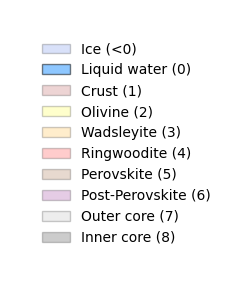

# Test for Earth

In [7]:
from astropy import constants as const
from astropy import units as u

# Constantes
r_s = const.R_sun.to(u.au).value.item() #UA
m_s= const.M_sun.to(u.kg).value.item() #kg
T_sol=5772 #K
M_t= const.M_earth.to(u.kg).value.item() #kg
R_t= const.R_earth.to(u.km).value.item() #km
P_t= 1 #atm
UA=1.496e+11#m
R_sol=6.96*10**8 #m

In [8]:
T_p=temp_pla2(T_sol, r_s, 1)
P_p=pressao(1, 1, 1, 1, 1, 3)

In [14]:
M=1; x_Fe_tot=38.0; x_H2O_tot=0.023
name='earth'
Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat = interior_structure(M,x_Fe_tot,x_H2O_tot, T_p, P_p)
#print(radius)


1.0000 Earth masses with 38.50% iron leads to planet radius 0.9999 (6370 km) with MOI factor 0.330


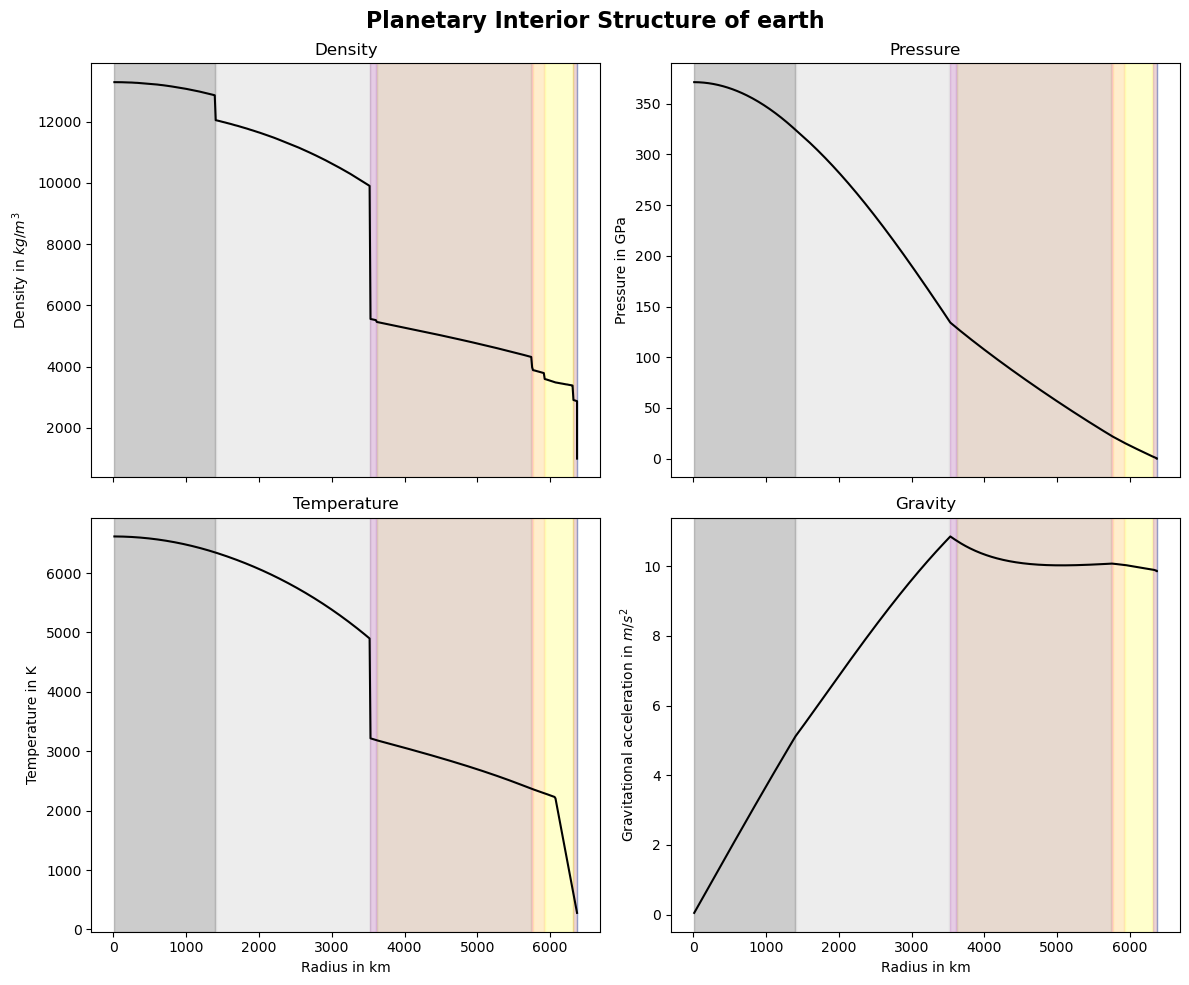

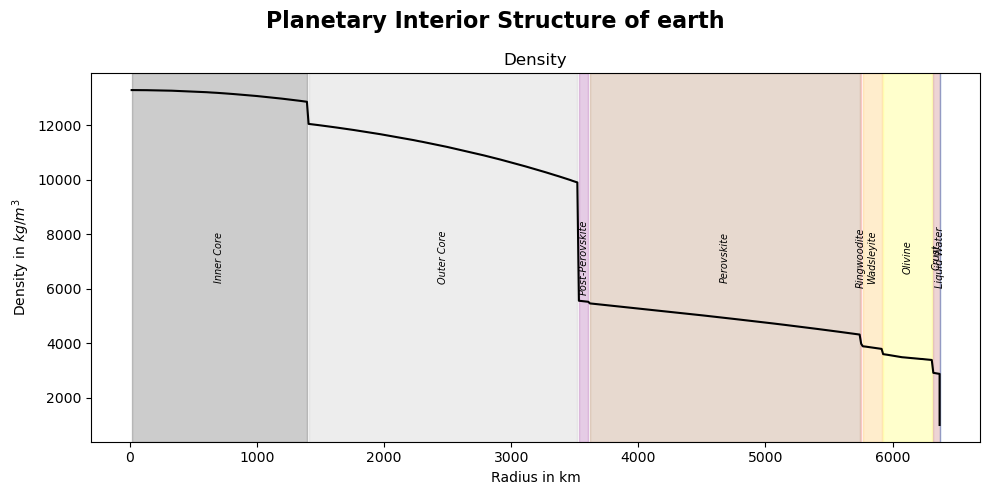

In [10]:
M=1; x_Fe_tot=38.5; x_H2O_tot=0.02
name='earth'
Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat = interior_structure(M,x_Fe_tot,x_H2O_tot, T_p, P_p)
#print(radius)
print('\n{0:6.4f} Earth masses with {1:5.2f}% iron leads to planet radius {2:6.4f} ({3:d} km) with MOI factor {4:5.3f}'
     .format(M,x_Fe_tot,Rp_E,int(Rp_E*6371),MOI))
visualization(Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat, name)
visualization2(Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat, name)

In [39]:
liquid_water    = np.where(mat < 0)[0]
crust           = np.where(mat == 1)[0]
olivine         = np.where(mat == 2)[0]
wadsleyite      = np.where(mat == 3)[0]
ringwoodite     = np.where(mat == 4)[0]
perovskite      = np.where(mat == 5)[0]
post_perovskite = np.where(mat == 6)[0]
outer_core      = np.where(mat == 7)[0]
inner_core      = np.where(mat == 8)[0]

layers = {
    "Liquid Water"   : liquid_water,
    "Crust"          : crust,
    "Olivine"        : olivine,
    "Wadsleyite"     : wadsleyite,
    "Ringwoodite"    : ringwoodite,
    "Perovskite"     : perovskite,
    "Post-Perovskite": post_perovskite,
    "Outer Core"     : outer_core,
    "Inner Core"     : inner_core,
}

print("=" * 75)
print(f"{'Layer':<20} {'Start (km)':>12} {'End (km)':>12} {'Thickness (km)':>15}")
print("=" * 75)
for name, indices in layers.items():
    if len(indices) > 0:
        if name=="Inner Core":
            r_start=0
            r_end     = radius[indices[-1]] / 1e3
            thickness = r_end - r_start
            print(f"{name:<20} {r_start:>12.3f} {r_end:>12.3f} {thickness:>15.3f}")
        else:
            r_start   = radius[indices[0]]  / 1e3
            r_end     = radius[indices[-1]] / 1e3
            thickness = r_end - r_start
            print(f"{name:<20} {r_start:>12.3f} {r_end:>12.3f} {thickness:>15.3f}")
    else:
        print(f"{name:<20} {'(absent)':>12} {'':>12} {'':>15}")
print("=" * 75)

Layer                  Start (km)     End (km)  Thickness (km)
Liquid Water             (absent)                             
Crust                    6321.012     6370.369          49.358
Olivine                  5926.149     6308.672         382.523
Wadsleyite               5765.736     5913.809         148.074
Ringwoodite              5753.396     5753.396           0.000
Perovskite               3618.669     5741.057        2122.388
Post-Perovskite          3532.292     3606.329          74.037
Outer Core               1405.354     3519.953        2114.599
Inner Core                  0.000     1392.220        1392.220


# APPLICATION FOR OTHER EXOPLAENTS

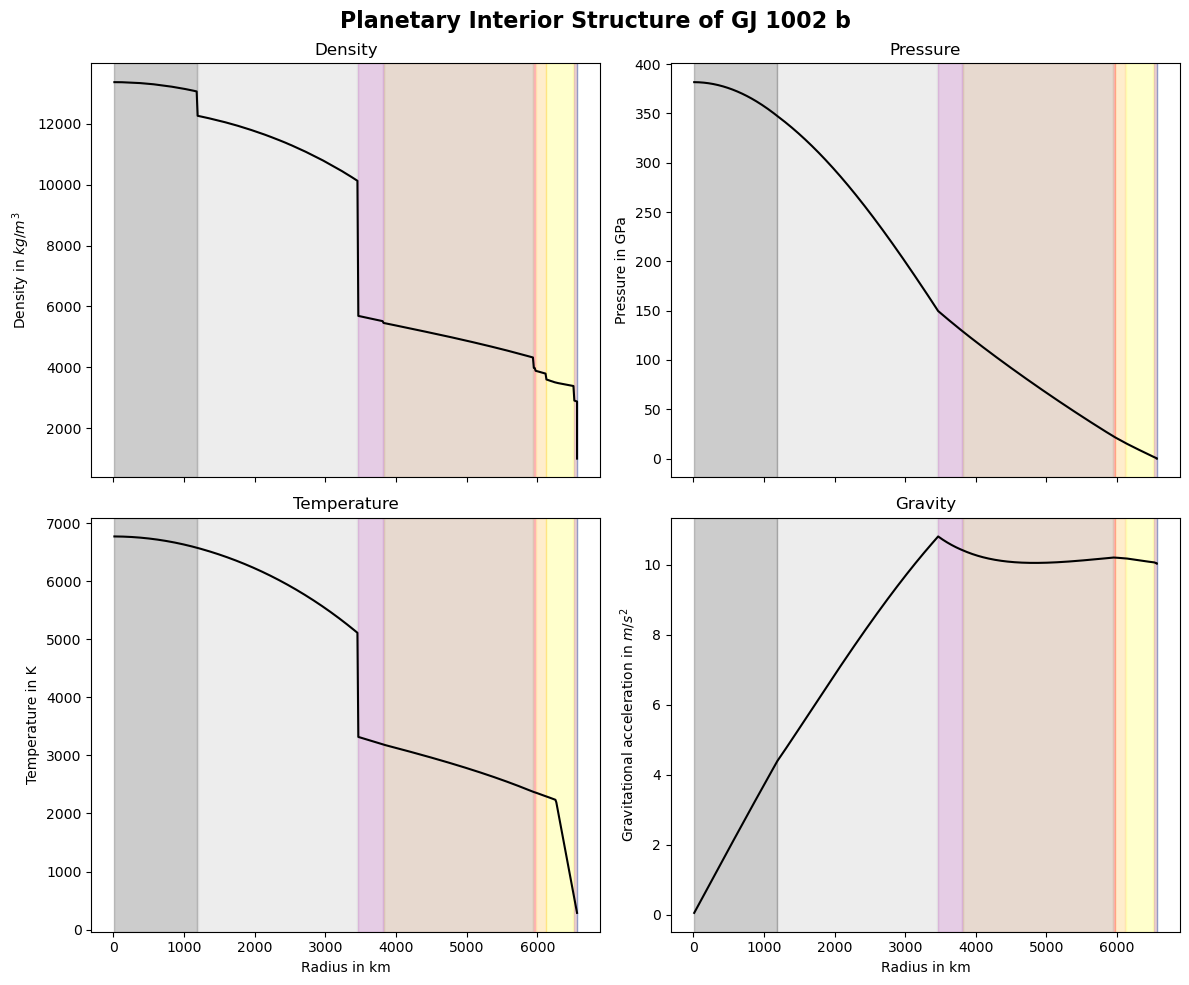

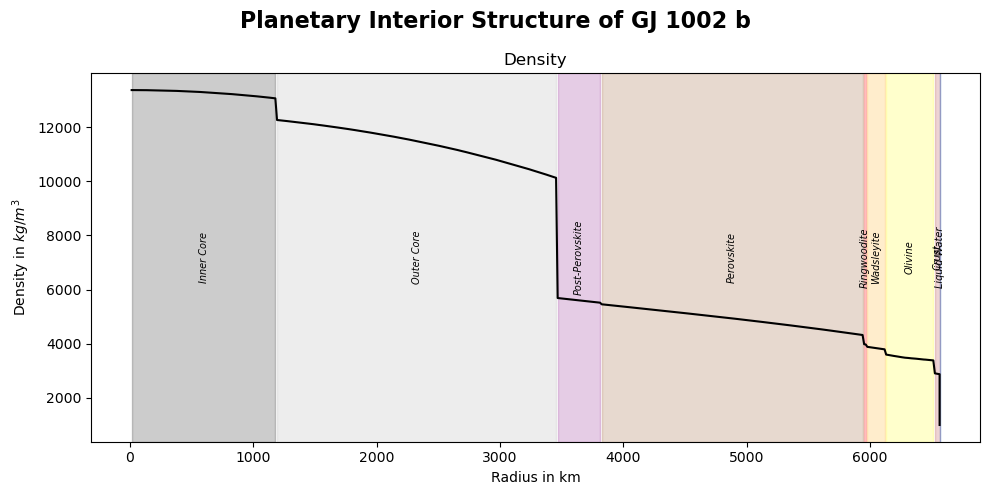

In [11]:
# To  GJ1002 B
name='GJ 1002 b'
mass_obs = 1.08 
radius_obs = 1.03
temp_obs = 288
P_p=1.05*10**5
# 1. Identificar o núcleo externo líquido (mat == 7)
Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat = interior_structure(mass_obs, 35.0, 0.06, temp_obs, P_p)

visualization(Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat, name)
visualization2(Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat, name)


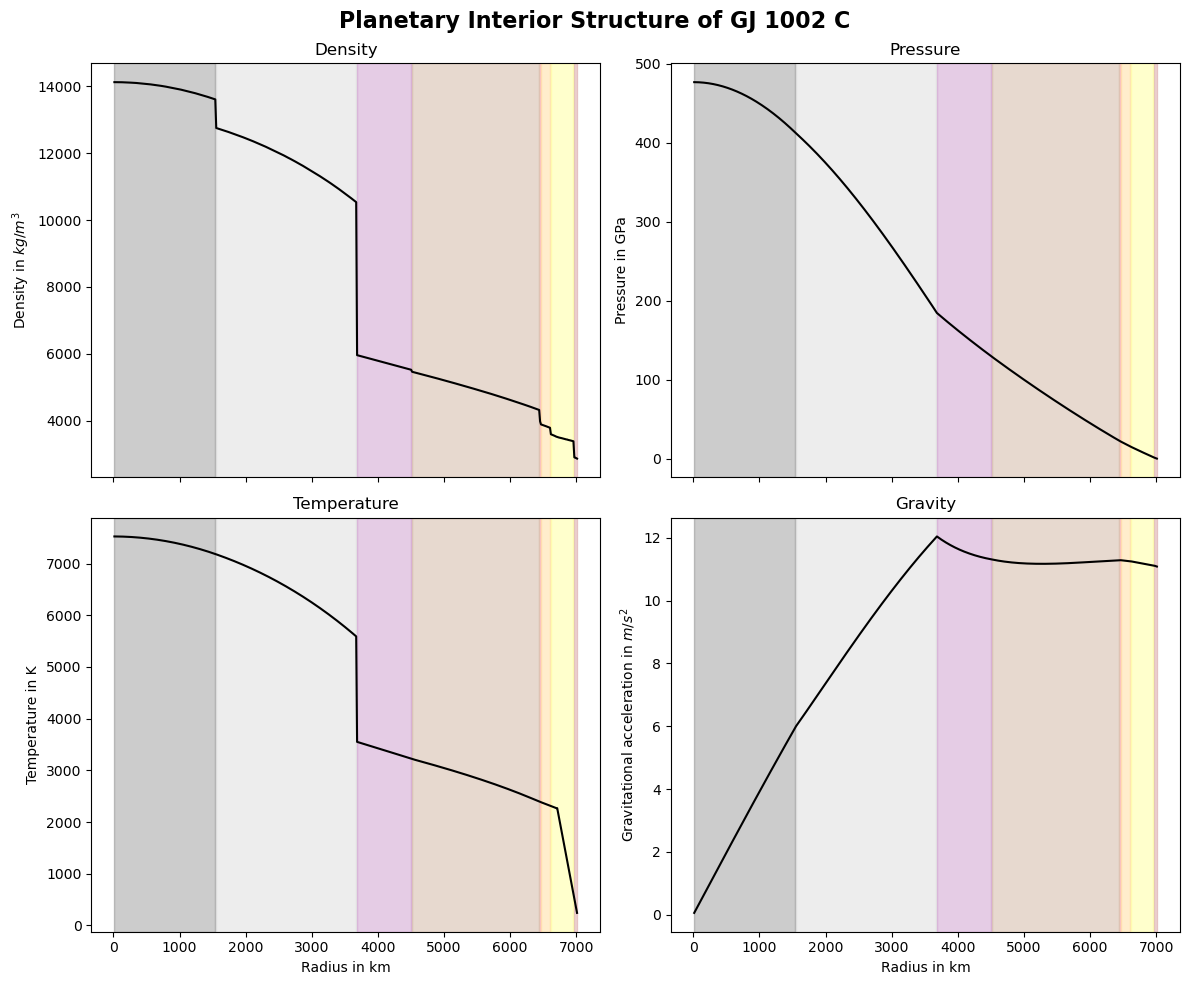

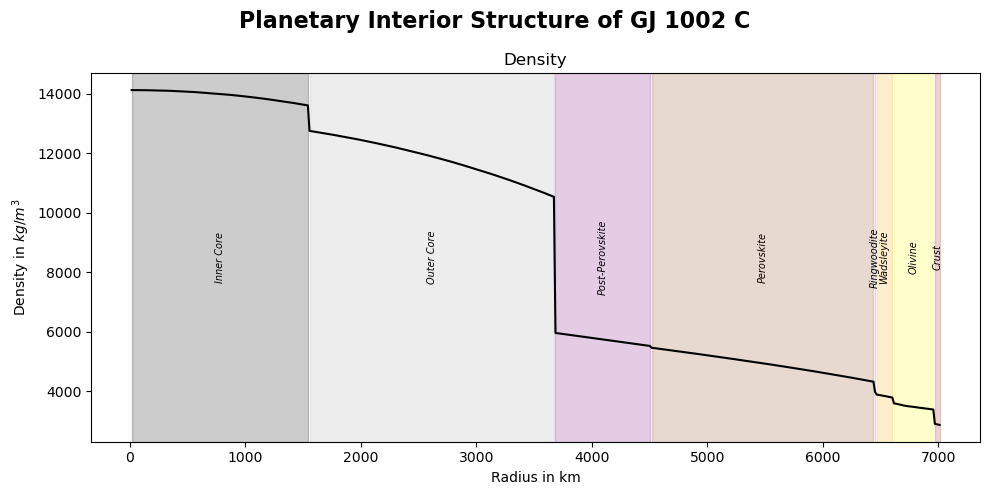

In [12]:
# To  GJ 1002 C
name='GJ 1002 C'
mass_obs = 1.36
radius_obs = 1.1
temp_obs = 242
P_p=1.28*10**5
Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat = interior_structure(mass_obs, 35.0, 0.0, temp_obs, P_p)

visualization(Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat, name)
visualization2(Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat, name)

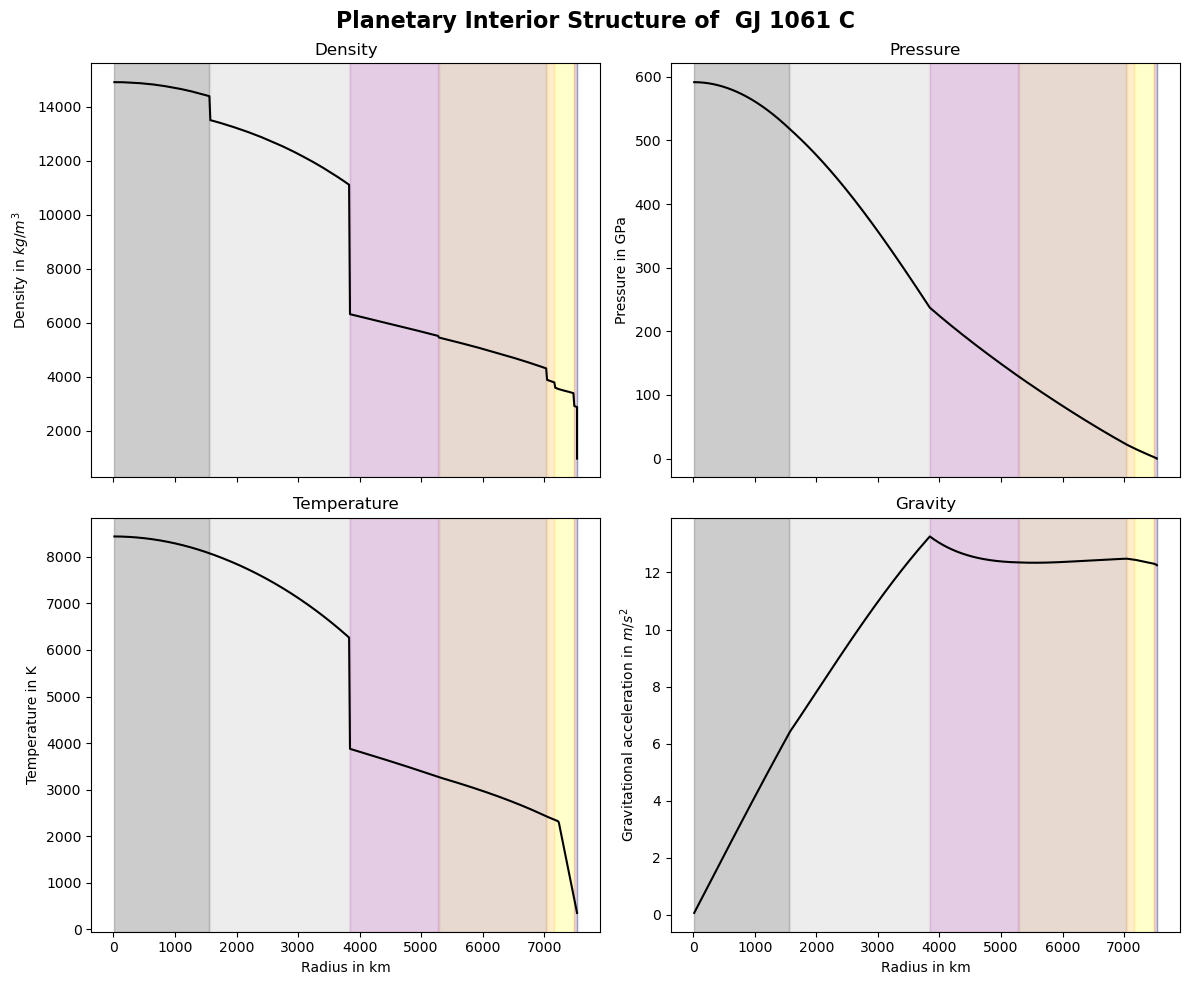

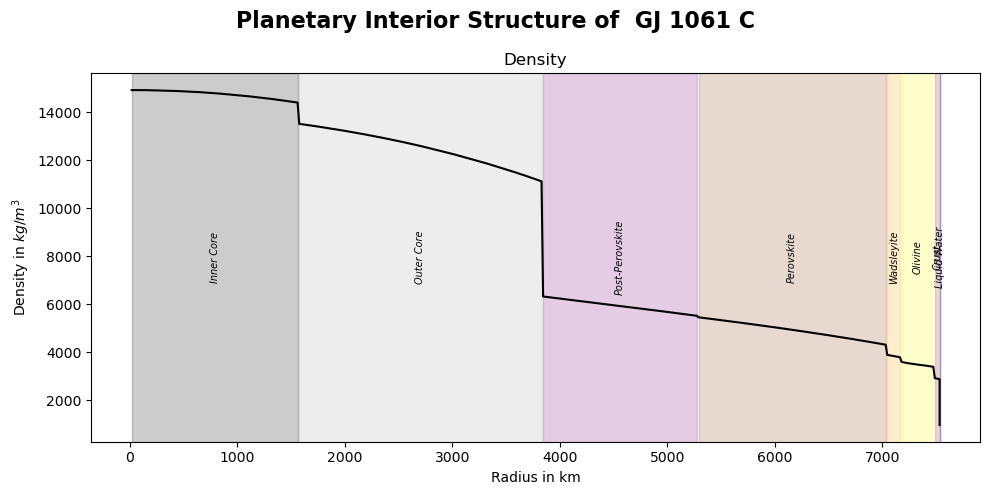

In [13]:
# To  GJ 1061 C

name=' GJ 1061 C'
mass_obs = 1.74
radius_obs = 1.18
temp_obs = 354
P_p=1.58*10**5
  

Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat = interior_structure(mass_obs, 33.250, 0.12, temp_obs, P_p)

visualization(Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat, name)
visualization2(Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat, name)

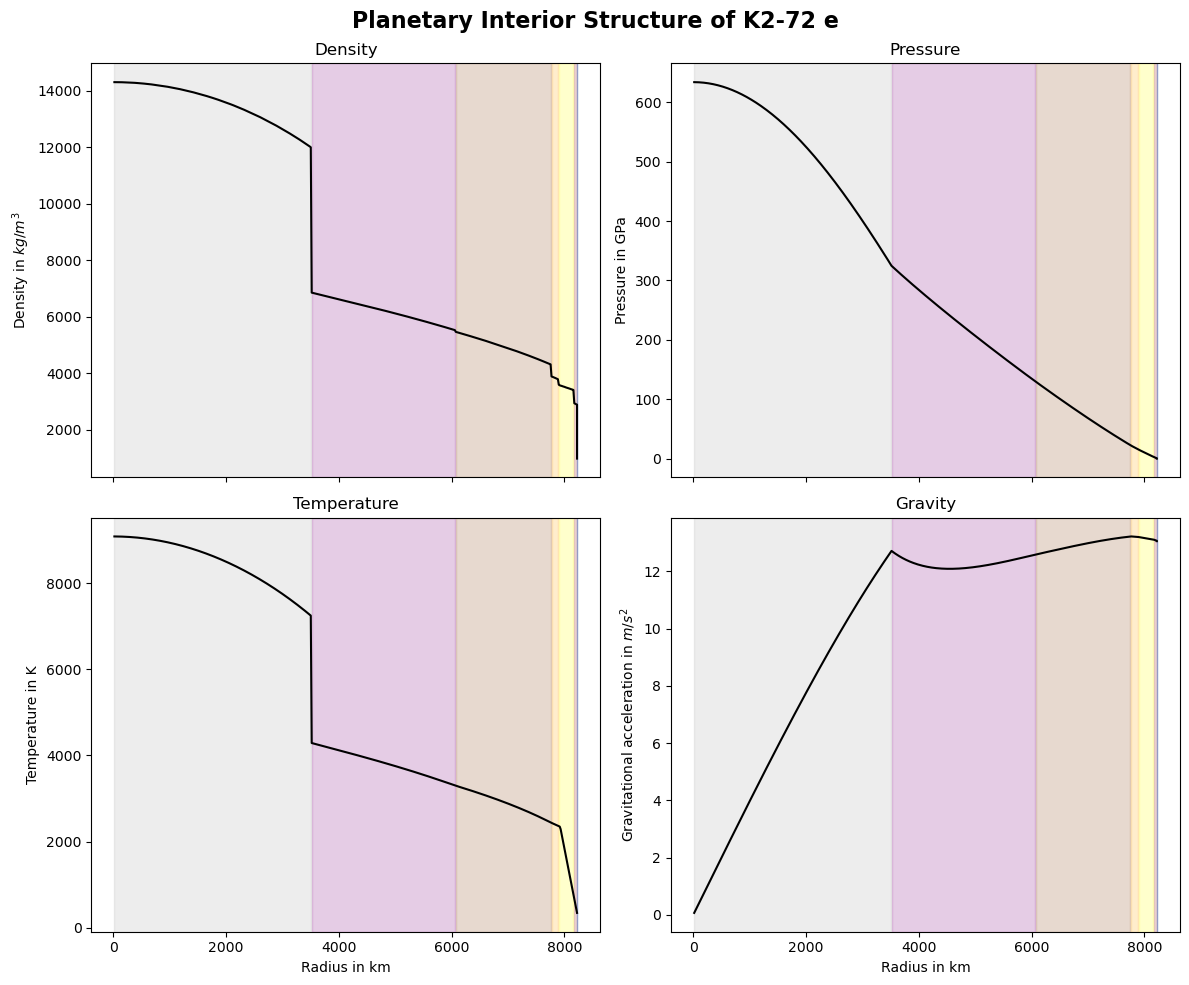

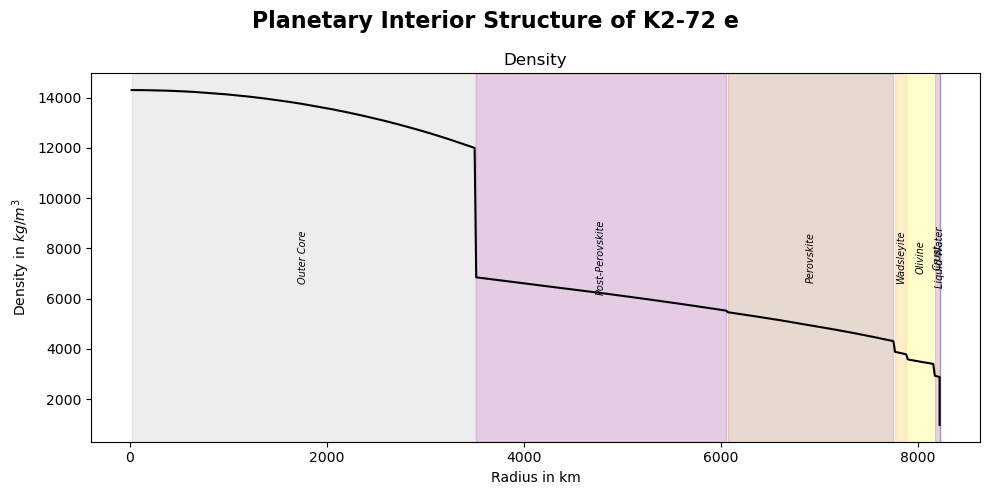

In [14]:
# To K2-72 E
name='K2-72 e'
mass_obs = 2.21
radius_obs = 1.29
temp_obs = 346
P_p=1.79*10**5
   

Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat = interior_structure(mass_obs, 23.75, 0.12, temp_obs, P_p)

visualization(Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat, name)
visualization2(Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat, name)

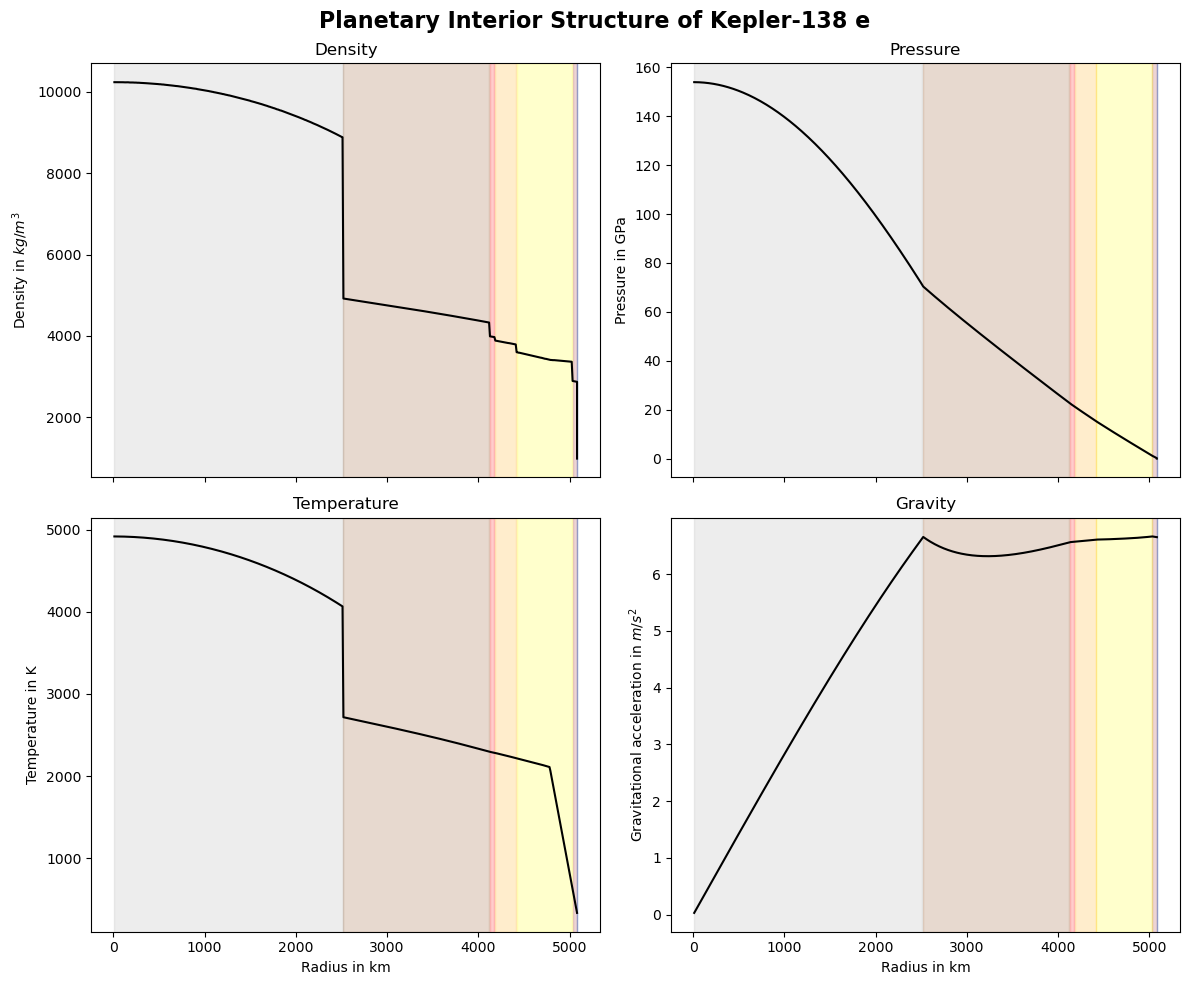

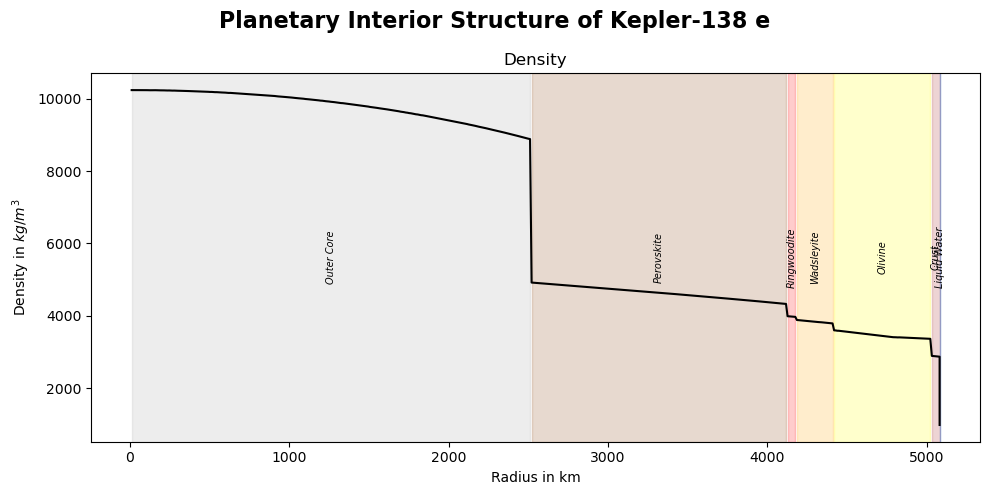

In [15]:
# To  Kep-138 e 
name='Kepler-138 e'
mass_obs = 0.43
radius_obs = 0.797
temp_obs = 335
P_p=0.46*10**5
   

Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat = interior_structure(mass_obs, 30.0, 0.12, temp_obs, P_p)

visualization(Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat, name)
visualization2(Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat, name)

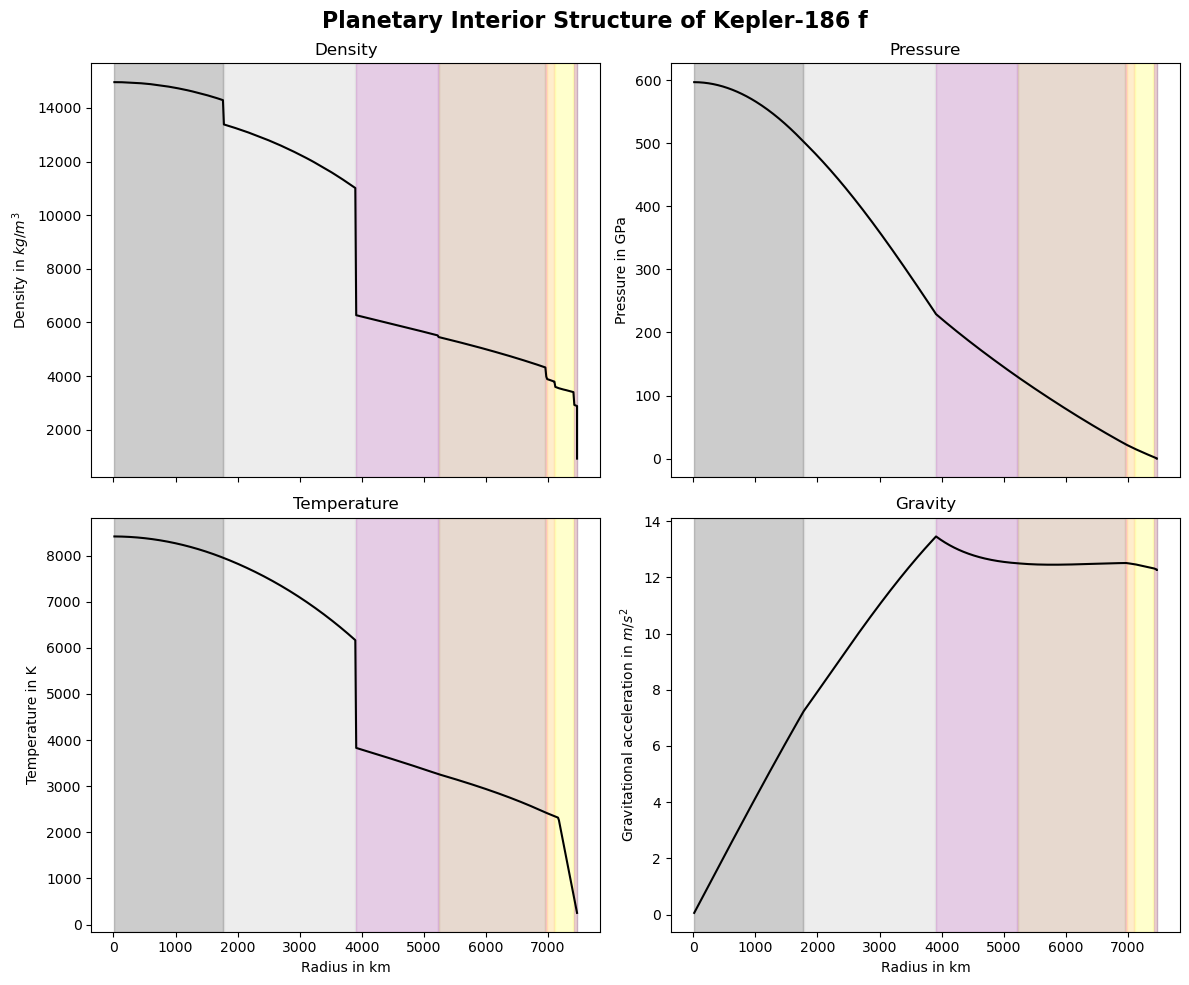

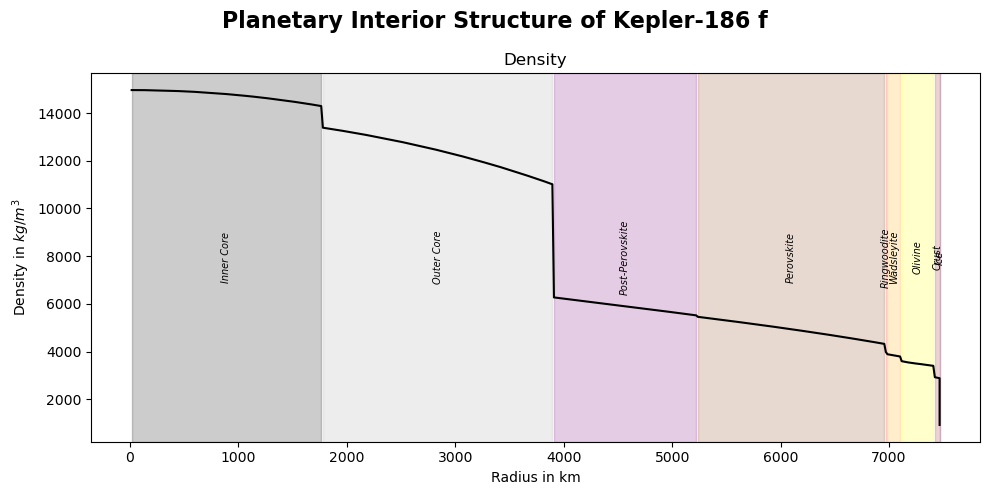

In [16]:
# To  Kepler-186 f
name='Kepler-186 f'
mass_obs = 1.71
radius_obs = 1.17
temp_obs = 253
P_p=1.58*10**5
    

Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat = interior_structure(mass_obs, 35.0, 0.12, temp_obs, P_p)
visualization(Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat, name)
visualization2(Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat, name)


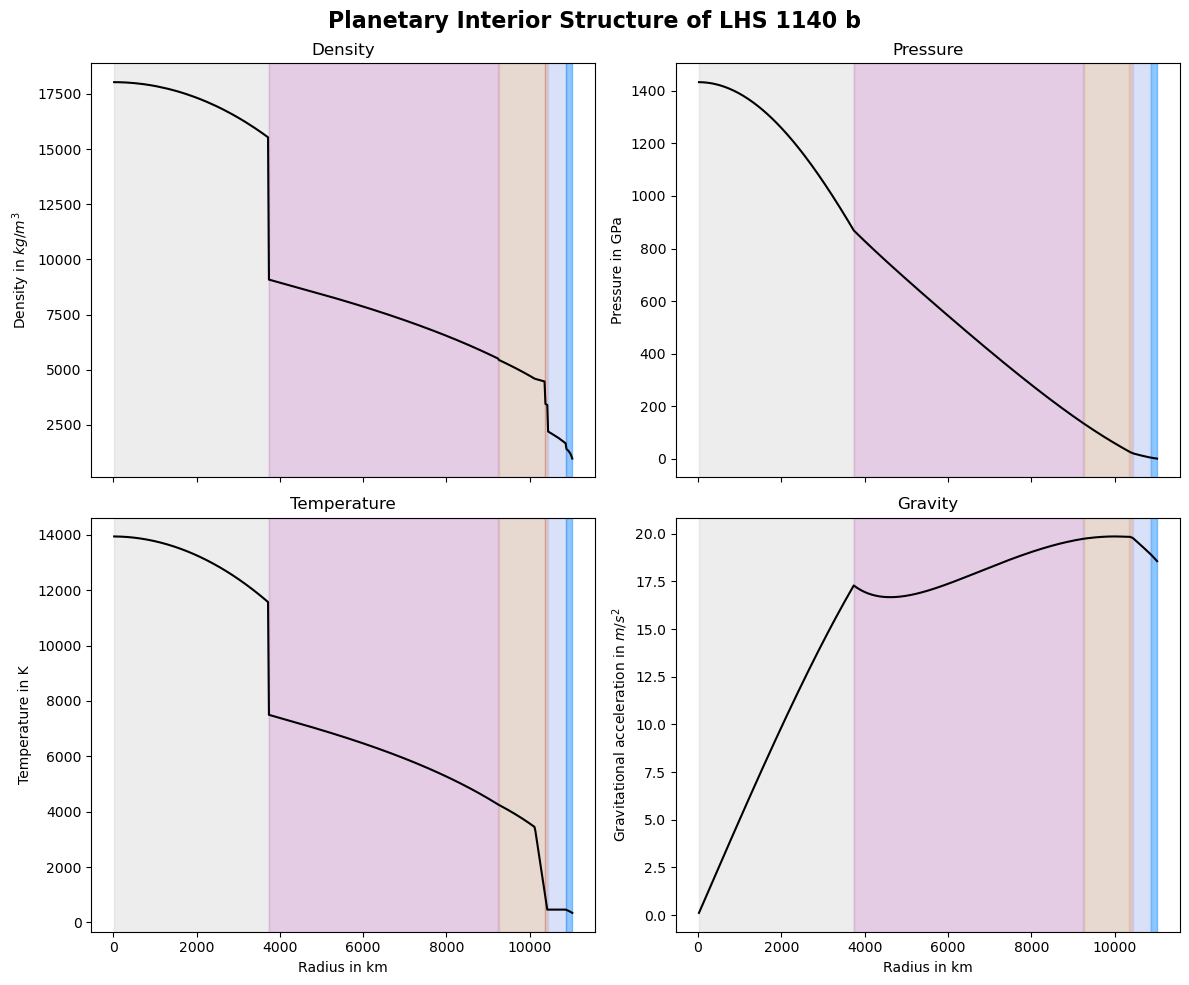

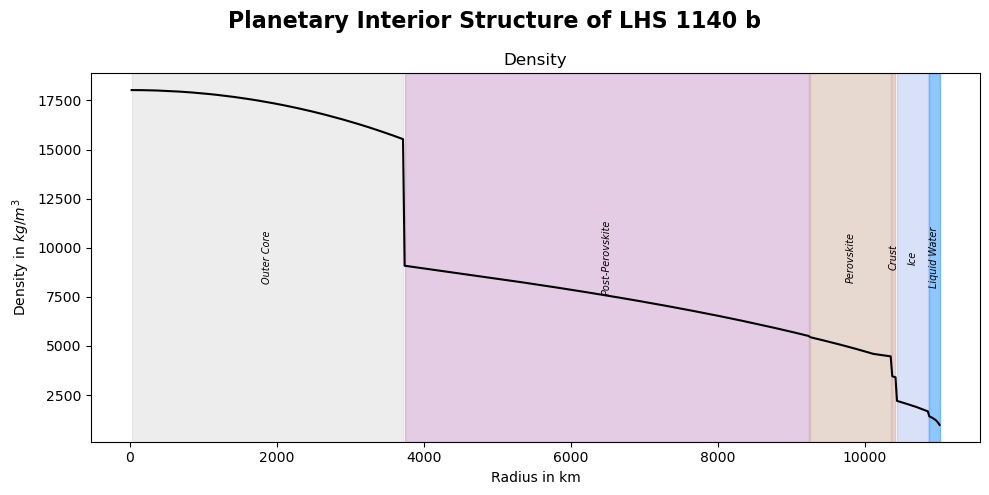

In [17]:
# To LHS 1140 b
name='LHS 1140 b'
mass_obs = 5.6
radius_obs = 1.73
temp_obs = 346
P_p=3.55*10**5
    

Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat = interior_structure(mass_obs, 17.0, 4.50, temp_obs, P_p)


visualization(Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat, name)
visualization2(Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat, name)


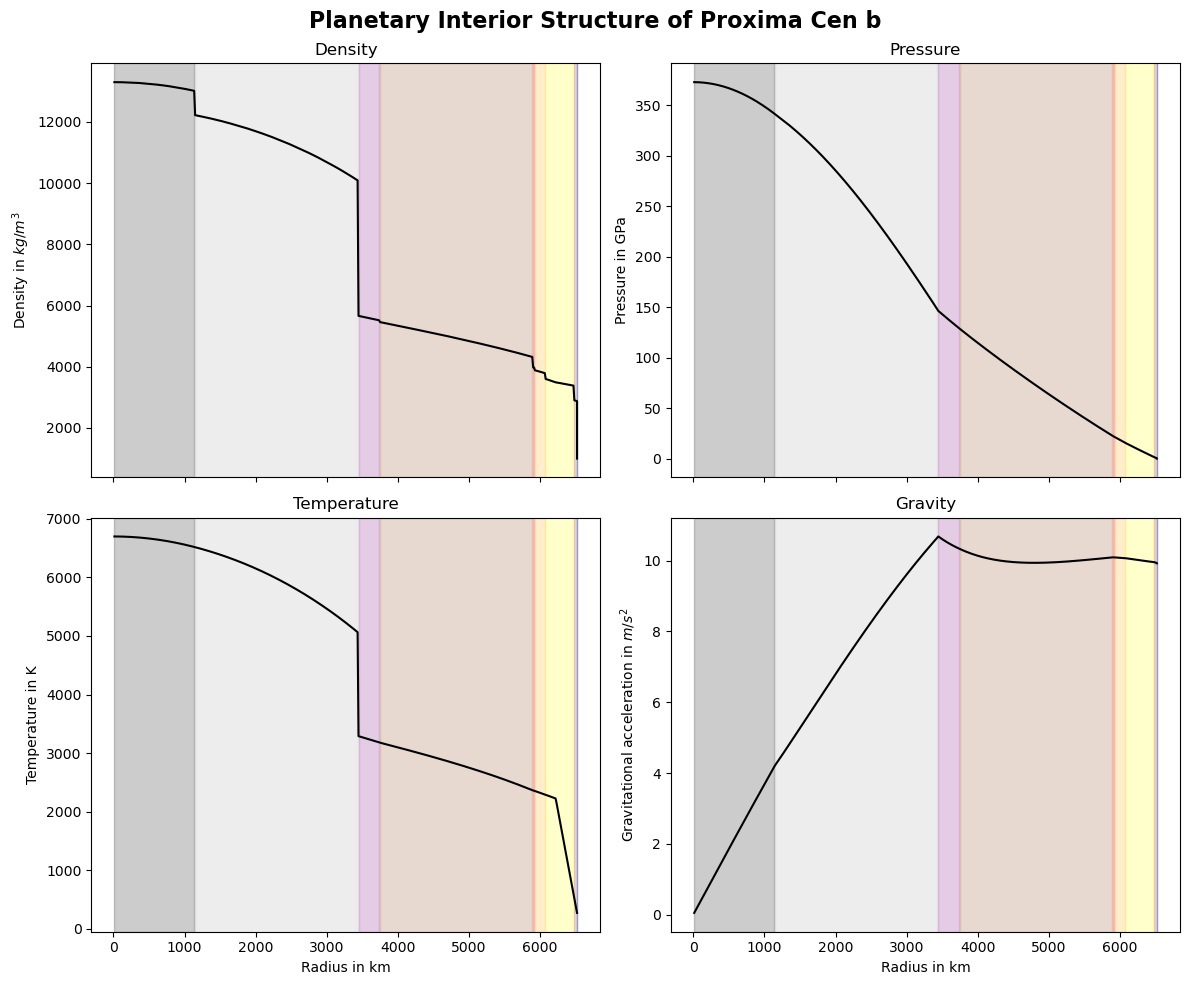

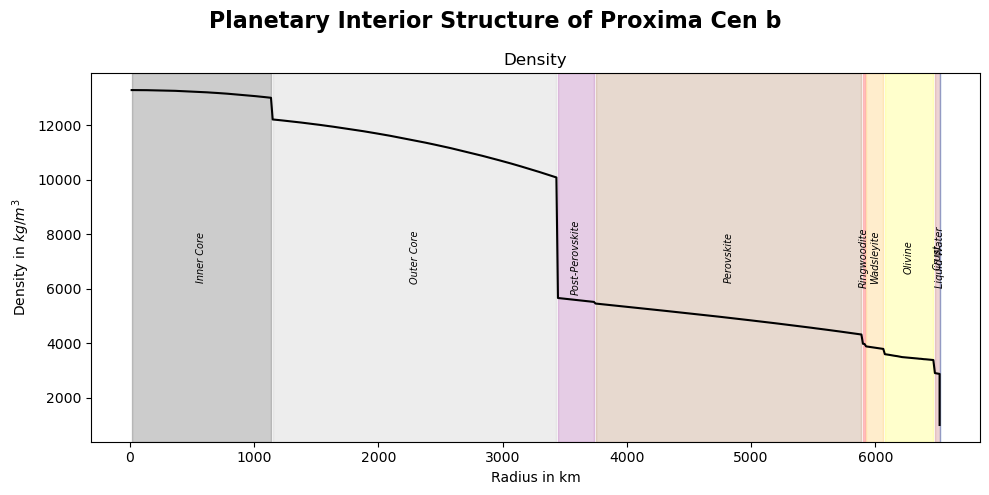

In [18]:
# To Proxima Cen b  
name='Proxima Cen b'
mass_obs = 1.055
radius_obs = 1.02
temp_obs = 274
P_p=1.04*10**5
    

Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat = interior_structure(mass_obs, 35.0, 0.12, temp_obs, P_p)

visualization(Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat, name)
visualization2(Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat, name)

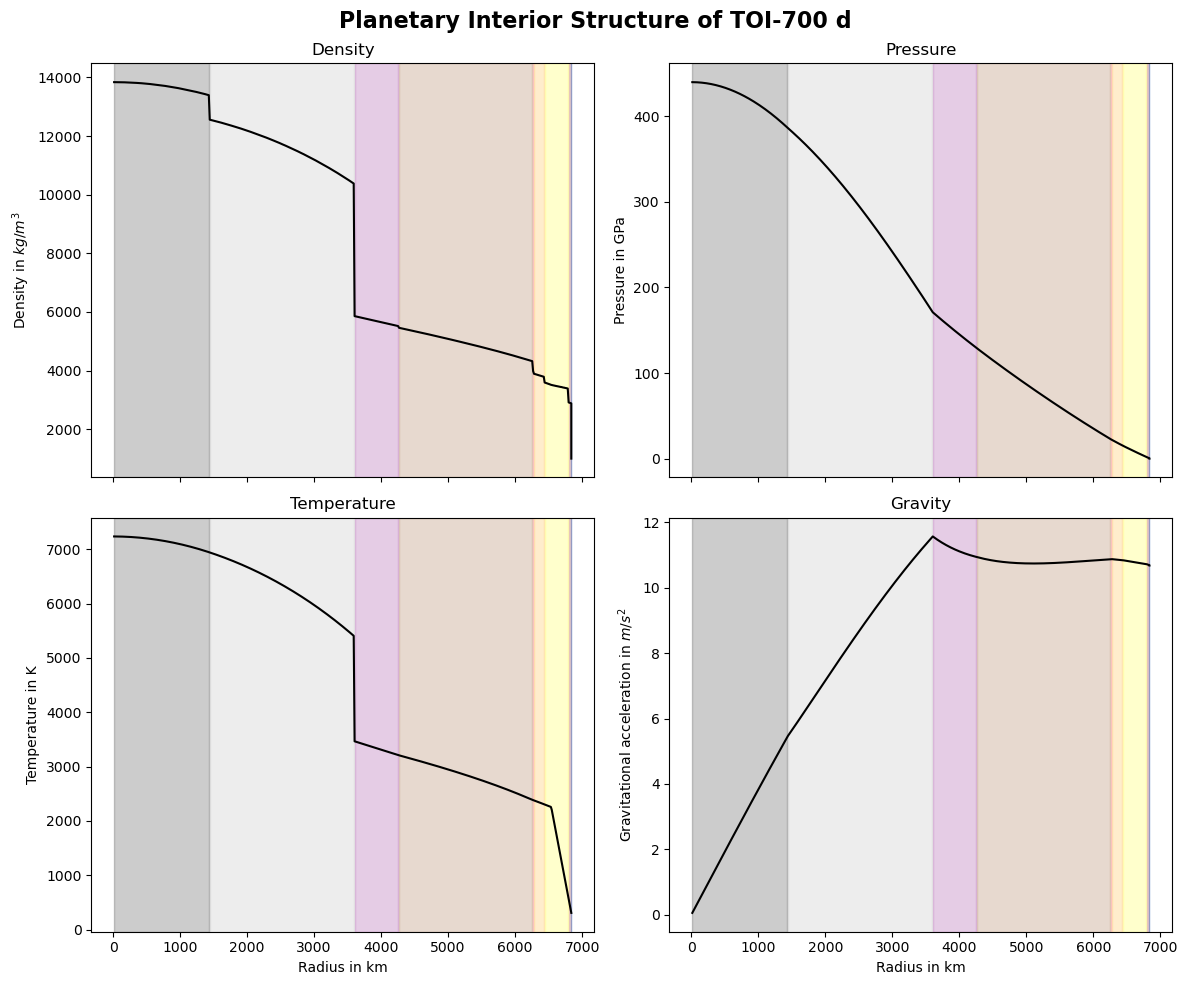

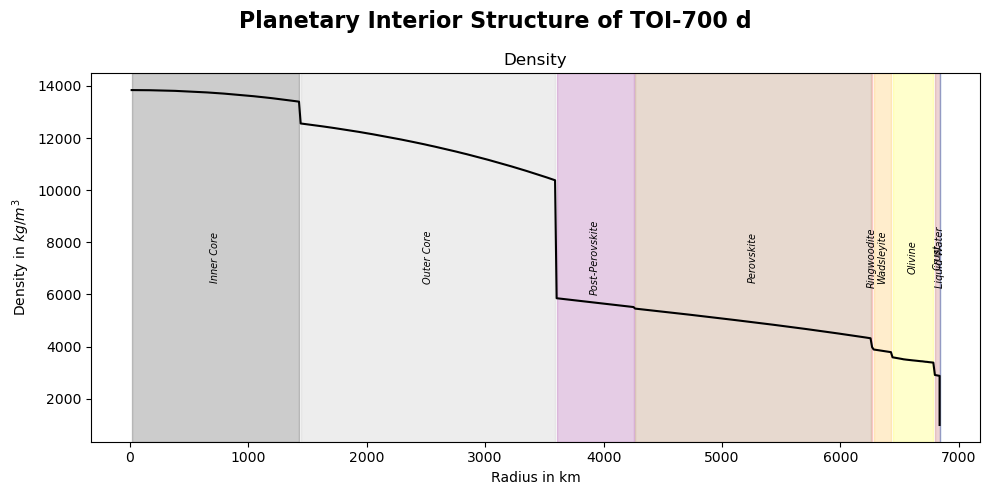

In [19]:
# To  TOI-700 d
name='TOI-700 d'
mass_obs = 1.25
radius_obs = 1.073
temp_obs = 308 
P_p=1.2*10**5
   

Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat = interior_structure(mass_obs, 35.0,0.12, temp_obs, P_p)


visualization(Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat, name)
visualization2(Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat, name)


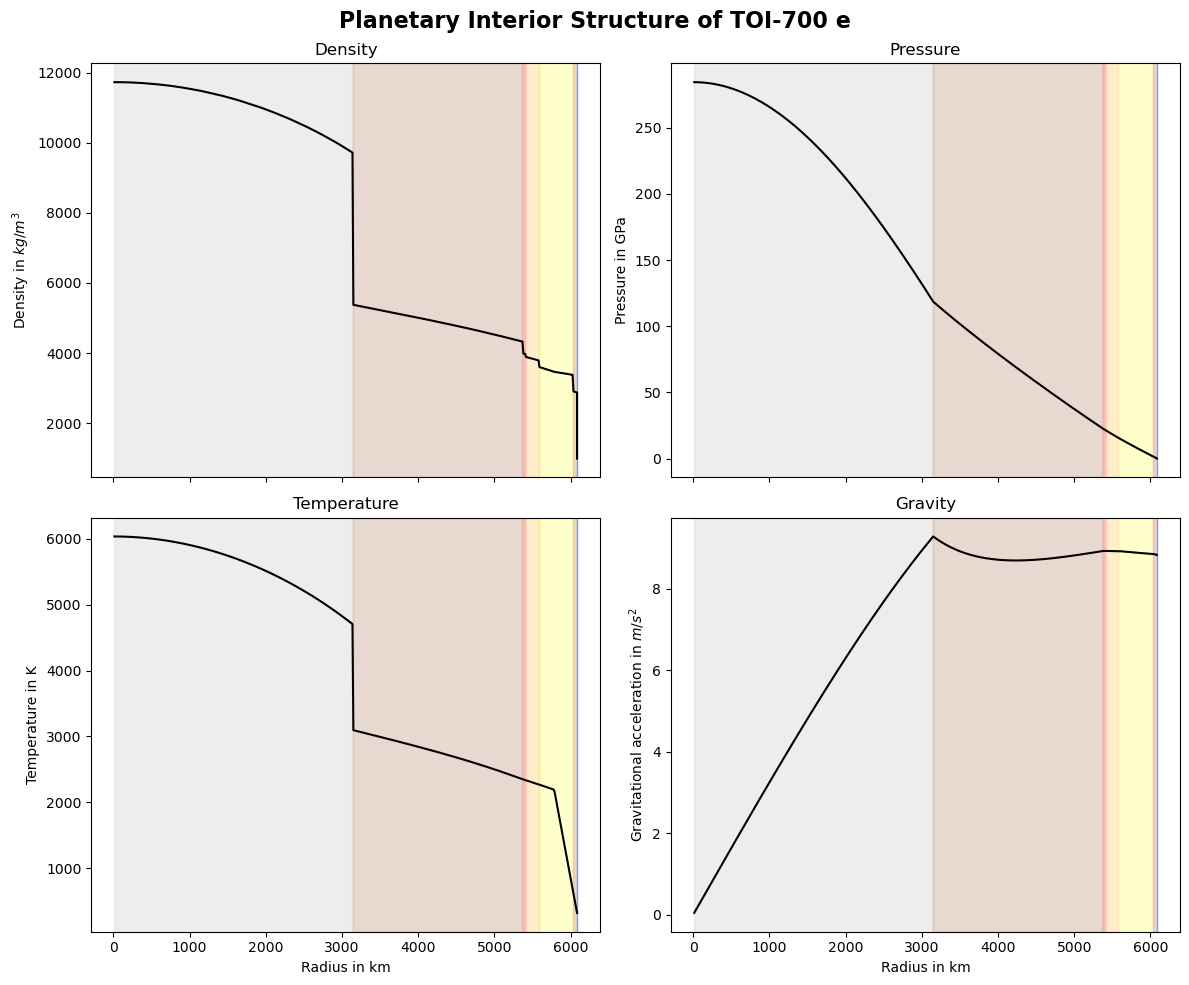

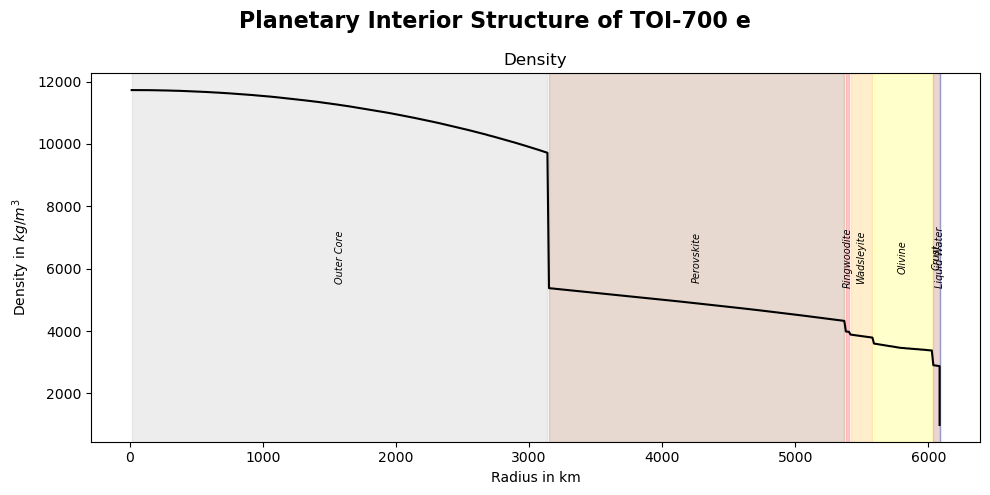

In [20]:
# To  TOI-700 e 
name='TOI-700 e'
mass_obs = 0.818
radius_obs = 0.953
temp_obs = 323
P_p=0.82*10**5
    
Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat = interior_structure(mass_obs, 33.250,0.12, temp_obs, P_p)


visualization(Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat, name)
visualization2(Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat, name)

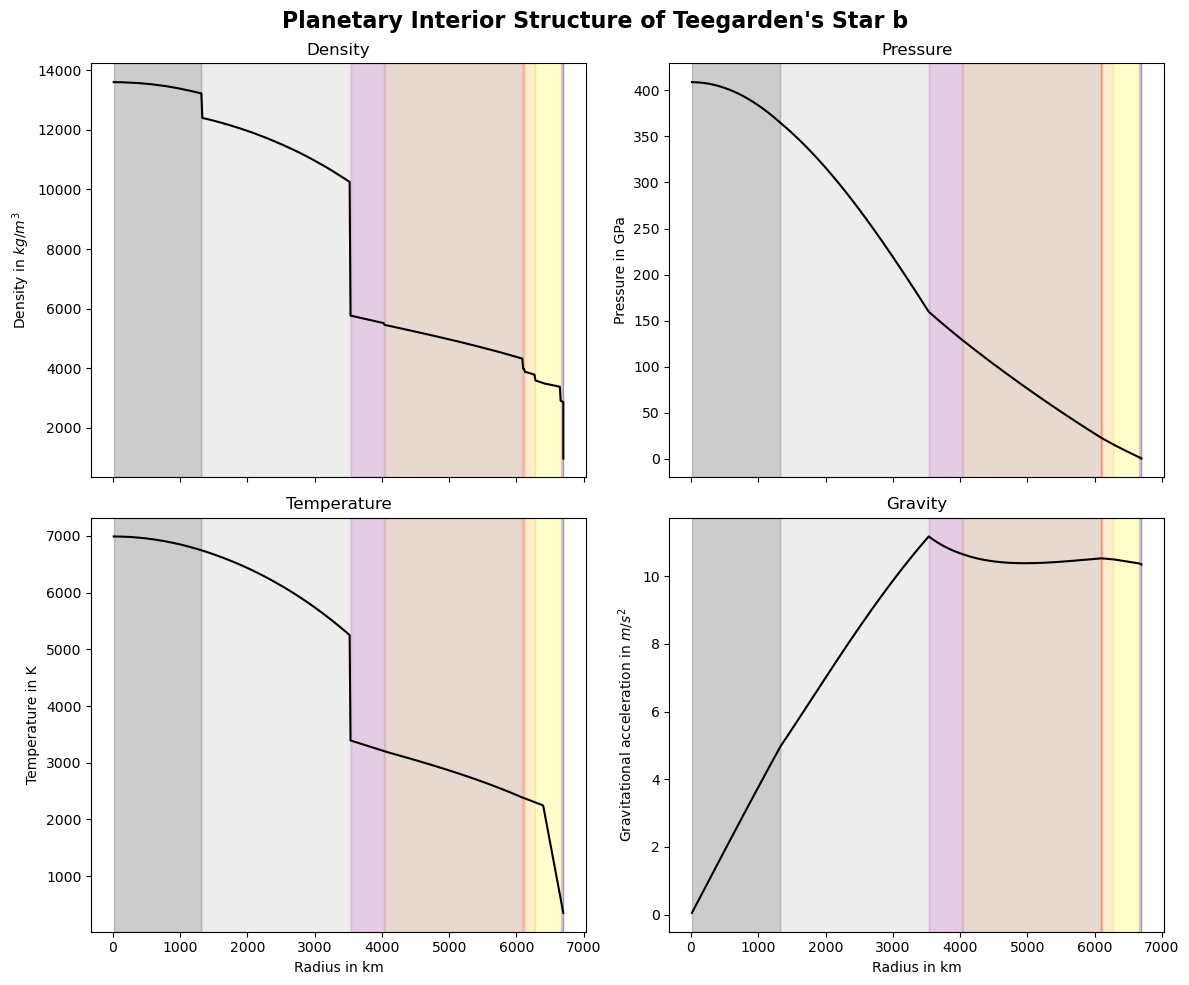

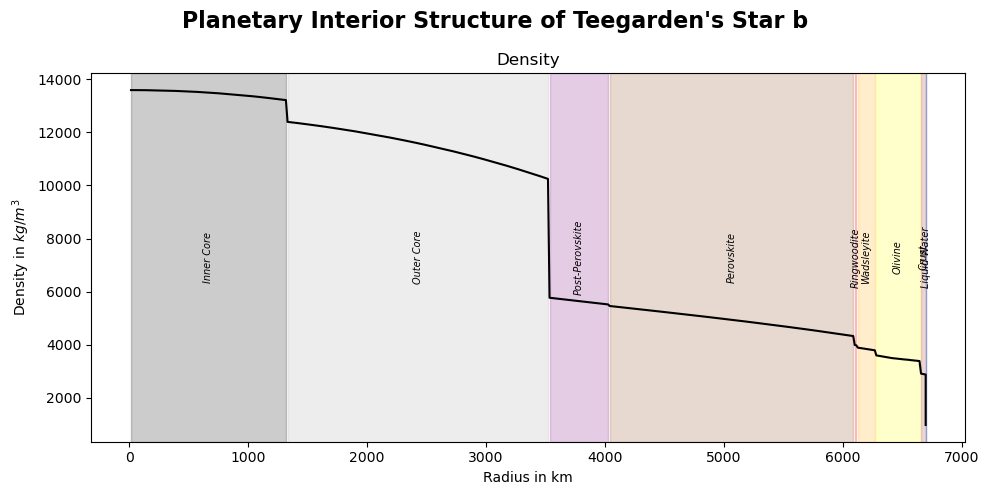

In [21]:
# To  Teegarden's Star b
name="Teegarden's Star b"
mass_obs = 1.16
radius_obs = 1.05
temp_obs = 353
P_p=1.12*10**5
    

Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat = interior_structure(mass_obs, 35.0,0.12, temp_obs, P_p)


visualization(Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat, name)
visualization2(Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat, name)

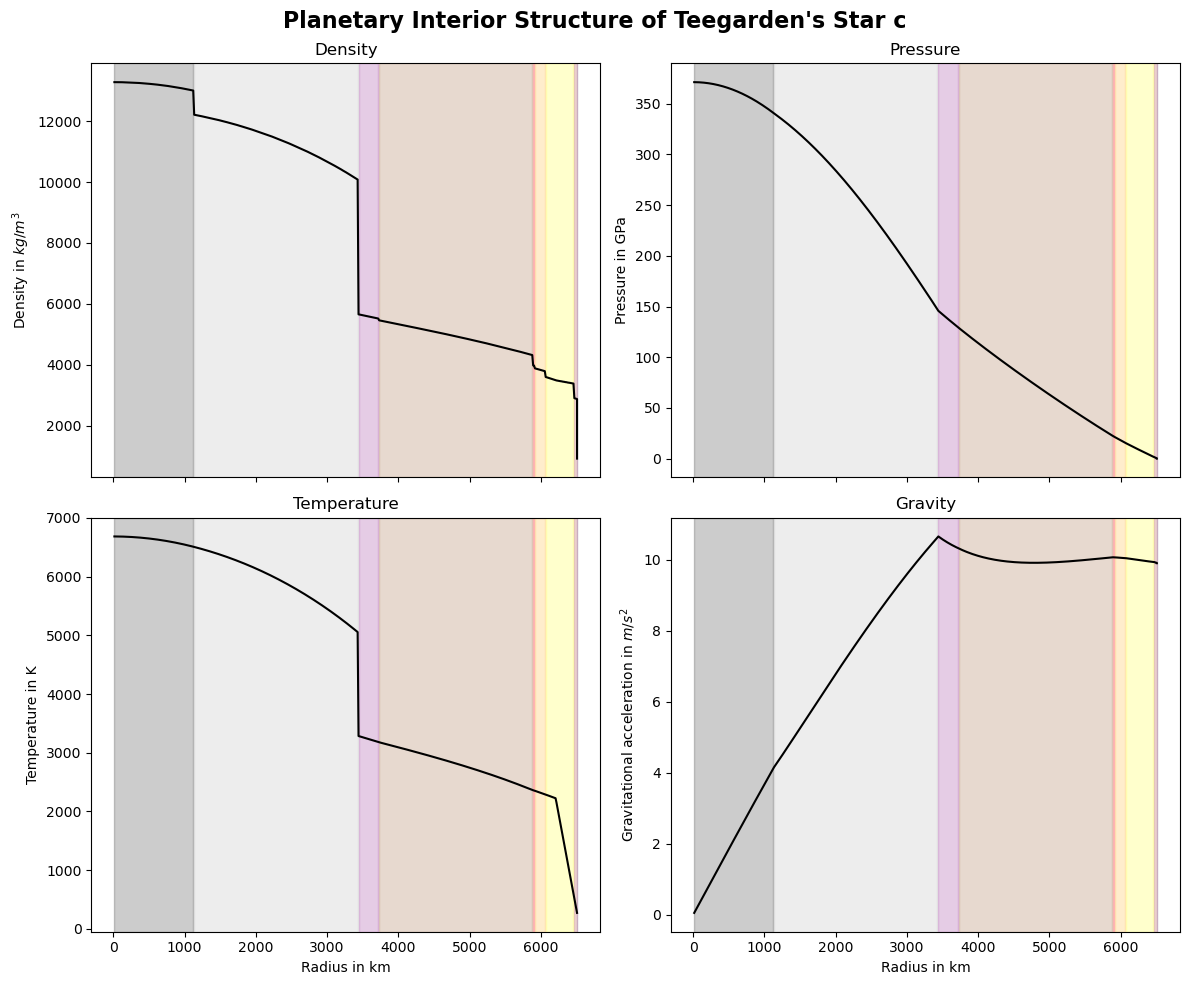

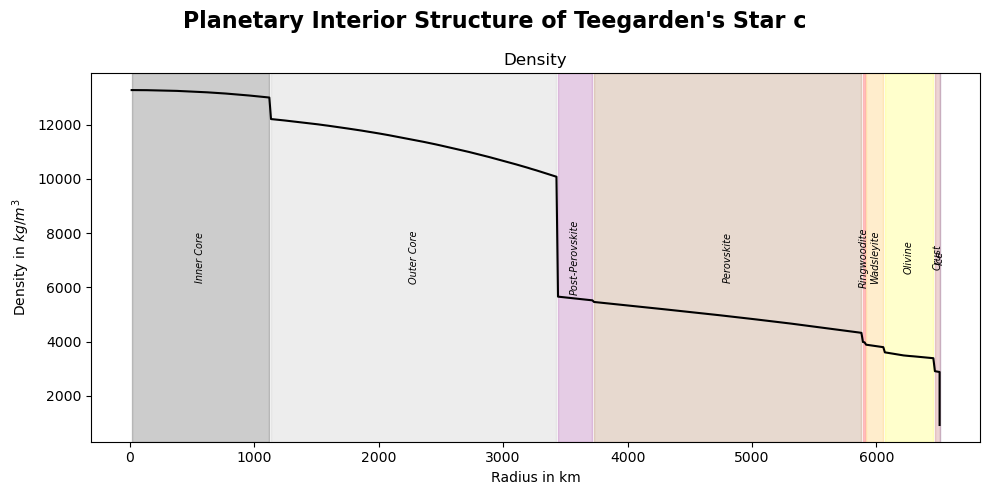

In [22]:
# To  Teegarden's Star c
name="Teegarden's Star c"
mass_obs = 1.05
radius_obs = 1.02
temp_obs = 273
P_p=1.03*10**5
    

Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat = interior_structure(mass_obs, 35.0, 0.12, temp_obs, P_p)
visualization(Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat, name)
visualization2(Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat, name)

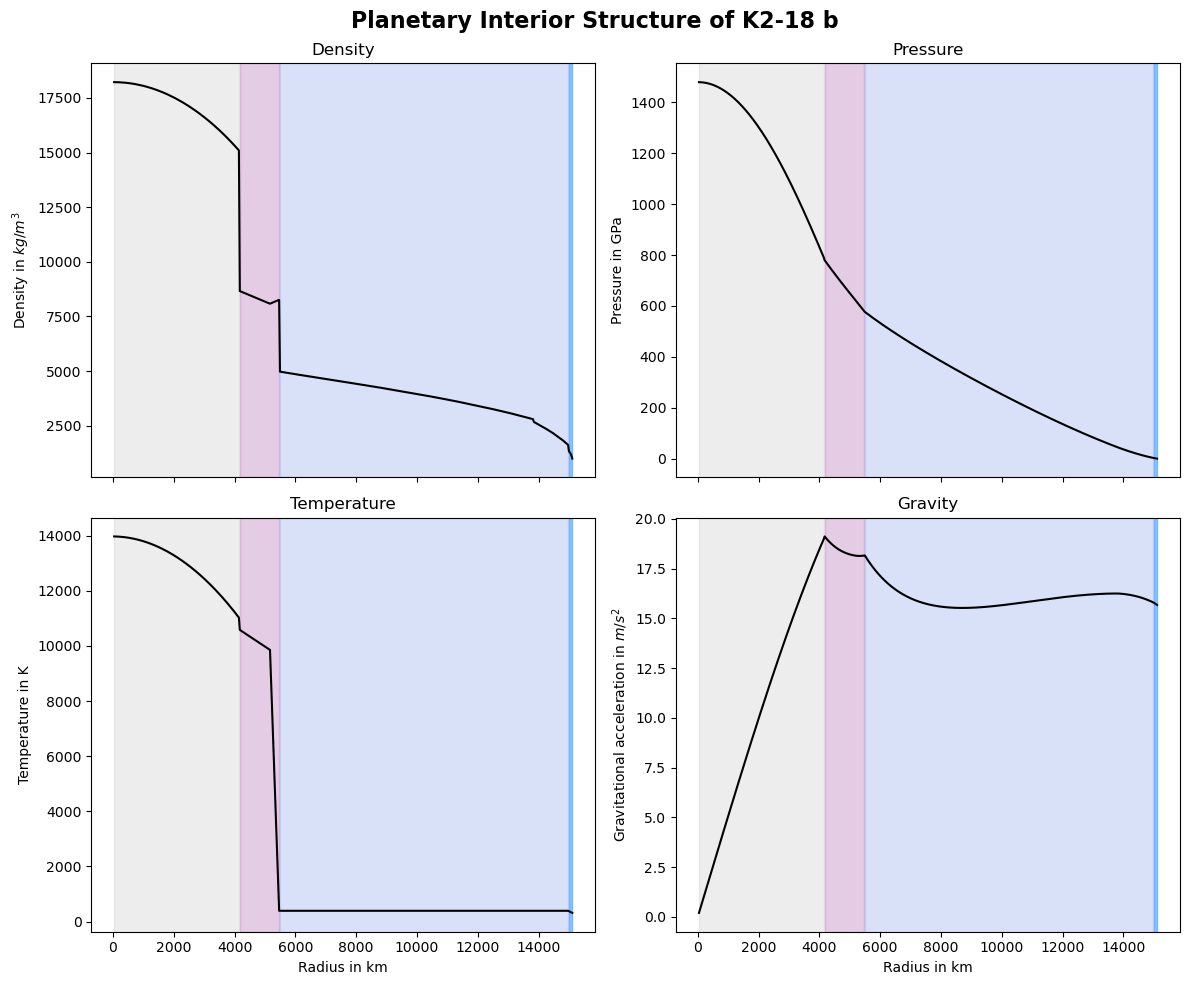

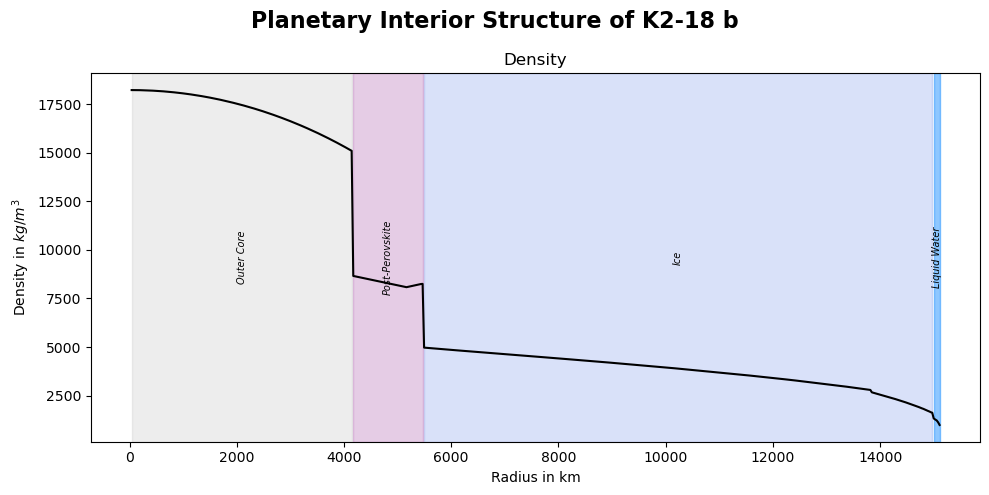

In [23]:
# To  K2-18 b
name="K2-18 b"
mass_obs = 8.92
radius_obs = 2.37
temp_obs = 317
P_p=2.56*10**5
    

Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat = interior_structure(mass_obs, 9.50, 85.0, temp_obs, P_p)
visualization(Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat, name)
visualization2(Rp_E,Rc_E,Rm_E,MOI,radius,density,gravity,pressure,temperature,alpha,cp,mass,elcond,vP,vS,KT,KS,mu,mat, name)